# MammoLens: Breast Cancer Detection on Mammograms

**Author:** Ibrahim Tamilore Esther

In this notebook I go back and fix a problem I found in my own data pipeline. It had quietly thrown away 246 full mammograms because of a gap in the dataset's metadata, so here I recover them, rebuild the manifest, split the data again, retrain and compare the result with my first run. I call this run v2, and its outputs are in `recovered_data_run/`.

> `README.md` explains all four runs I did and which one I am reporting as my main result.

> This is an academic prototype. It is not a medical device and it must not be used to make decisions about anyone's care.

> **Where this run sits.** This is my v2 rebuild, run end to end on a Colab T4 on 22 September 2026. Section 2.3 recovers full mammograms that my v1 linkage had discarded, Sections 3.1 and 3.2 rebuild the manifest and the split, Section 4 retrains from ImageNet-pretrained weights with a per-epoch log, and Sections 5 and 6 re-evaluate. Section 5.8 compares v1 with v2.
>
> The headline result is negative, and I have left it that way: my rebuilt dataset is larger and the retrained model is worse, including on the images both runs held out. Section 5.8 lays out the evidence and Section 7 says what it does and does not establish. My v1 run is preserved with its outputs and prose in `MammoLens.ipynb`, and its artefacts sit in `initial_run/results/`, `initial_run/checkpoints/`, `initial_run/figures/` and `initial_run/manifests/`, which this notebook only reads.

<a id="abstract"></a>
## Abstract

This notebook is where I rebuilt the MammoLens dataset and retrained on it. Auditing my first run, I found that 282 abnormality rows had been thrown away because the metadata rows they point to carry a blank series label. Section 2.3 classifies the 246 images behind those rows from their own pixels and accepts all 246 as full mammograms. My rebuilt dataset holds 3085 images from 1565 patients, which is 228 images and 105 patients more than before. A patient-grouped, density-stratified split gives 2210 training, 445 validation and 430 test images. I fine-tuned EfficientNet-B0 again with the hyperparameters unchanged, and it stopped early at epoch 10 with its best validation AUC of 0.7478 at epoch 5. On the new test set it reached an AUC of 0.6627, against 0.7541 for my earlier model on the earlier test set. On the 48 images both runs held out, the earlier model scored 0.7622 and the new one 0.5822, a paired difference of -0.1801 (95% confidence interval -0.3389 to -0.0247). So recovering the images made my dataset bigger without making the model better, and this notebook does not establish why.

## Contents

- [Abstract](#abstract)
- [1 Setup and environment](#s1)
  - [1.1 Runtime and dependencies](#s1-1)
  - [1.2 Configuration](#s1-2)
  - [1.3 Snapshot of the v1 run](#s1-3)
- [2 Data acquisition and linkage](#s2)
  - [2.1 Extracting the CBIS-DDSM archive](#s2-1)
  - [2.2 Inspecting the raw metadata](#s2-2)
  - [2.3 Recovering images with a blank series label](#s2-3)
- [3 Preprocessing and patient-grouped split](#s3)
  - [3.1 Rebuilding the manifest](#s3-1)
  - [3.2 Re-splitting the rebuilt dataset](#s3-2)
  - [3.3 Image preprocessing and split composition](#s3-3)
  - [3.4 Local image cache](#s3-4)
- [4 Model and training](#s4)
  - [4.1 Retraining on the rebuilt dataset](#s4-1)
  - [4.2 Training log and learning curve](#s4-2)
- [5 Evaluation](#s5)
  - [5.1 Test-set evaluation procedure](#s5-1)
  - [5.2 Aggregate performance](#s5-2)
  - [5.3 Density-stratified performance](#s5-3)
  - [5.4 Best-checkpoint evaluation and export](#s5-4)
  - [5.5 Density comparison chart](#s5-5)
  - [5.6 Supplementary checks](#s5-6)
    - [5.6.1 Per-image predictions](#s5-6-1)
    - [5.6.2 Discrimination on training, validation and test data](#s5-6-2)
    - [5.6.3 Hyperparameters](#s5-6-3)
    - [5.6.4 Storage timing](#s5-6-4)
  - [5.7 Statistical analysis of the density gap](#s5-7)
    - [5.7.1 Bootstrap confidence intervals](#s5-7-1)
    - [5.7.2 Testing the density gap](#s5-7-2)
    - [5.7.3 Operating points at a specificity of 0.80](#s5-7-3)
    - [5.7.4 Calibration by density](#s5-7-4)
    - [5.7.5 Saving the results](#s5-7-5)
  - [5.8 Comparing v1 with v2](#s5-8)
    - [References for Sections 5.6 to 5.8](#s5-7-refs)
- [6 Interpretability (Grad-CAM)](#s6)
  - [6.1 Curated Grad-CAM gallery](#s6-1)
- [7 Limitations](#s7)
- [8 References](#s8)

Tables: [1](#t1) raw metadata; [2](#t2) recovered candidate classification; [3](#t3) cleaning counts v1 against v2; [4](#t4) the v2 split; [5](#t5) split composition; [6](#t6) training log; [7](#t7) test metrics; [8](#t8) best-checkpoint test metrics; [9](#t9) bootstrap confidence intervals; [10](#t10) operating points; [11](#t11) v1 against v2. Supplementary: [S1](#ts1) AUC by split; [S2](#ts2) hyperparameters; [S3](#ts3) storage timing.

Figures: [1](#f1) recovered candidates; [2](#f2) learning curve; [3](#f3) density comparison; [4](#f4) calibration by density; [5](#f5) Grad-CAM gallery.

<a id="s1"></a>
## 1 Setup and environment

<a id="s1-1"></a>
### 1.1 Runtime and dependencies

I ran this on Google Colab with the project folder on Google Drive at `/content/drive/MyDrive/MammoLens`. The cell below mounts Drive, makes the project root the working directory and adds it to `sys.path` so I can import the modules in `src/` as a package. Then it installs what `requirements.txt` lists and prints the PyTorch build (Paszke et al., 2019) and the GPU. I bounded the requirements from below only, so pip keeps Colab's preinstalled CUDA build of PyTorch instead of replacing it.

Keeping the data, checkpoints and results on Drive rather than on the Colab machine was deliberate. Colab sessions are temporary and drop without warning, and anything written only under `/content` goes with them. Drive is slower to read from, which Section 3.4 works around for the images, but a checkpoint written to Drive at the end of an epoch survives a disconnect. My reusable code lives in `src/` for a related reason: the same training function can be run from the command line with `python -m src.train`, and the notebook stays readable.

In [1]:
# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Locate the project on Drive ---
import os, sys
PROJECT_DIR = '/content/drive/MyDrive/MammoLens'
assert os.path.isdir(PROJECT_DIR), f'Project not found at {PROJECT_DIR} — upload the repo there.'
os.chdir(PROJECT_DIR)
sys.path.append(PROJECT_DIR)  # so `import src...` works

# --- Install dependencies ---
!pip install -q -r requirements.txt

# --- Check GPU availability ---
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('No GPU detected — set Runtime → Change runtime type → GPU.')

Mounted at /content/drive
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


The run used PyTorch `2.11.0+cu128` on a single Tesla T4, the same class of GPU as my v1 run. Reproducing these numbers exactly needs that combination: some GPU kernels are not deterministic, and mixed precision makes small differences at the fourth decimal place likely on other hardware even with the same seed.

<a id="s1-2"></a>
### 1.2 Configuration

Every path and hyperparameter comes from `configs/config.yaml` through `src.config.load_config`, and `ensure_dirs` creates the checkpoint and log folders if they are missing. Keeping all the tunable values in one YAML file, rather than scattering them through the notebook and the modules, means a change of setting leaves a trace in one place and the training code reads exactly what the file says. The cell prints the four settings I refer to most when reading the results.

In [2]:
from src.config import load_config, ensure_dirs

cfg = load_config('configs/config.yaml')
ensure_dirs(cfg)
print('Batch size:', cfg.train.batch_size)
print('Learning rate:', cfg.train.learning_rate)
print('Epochs:', cfg.train.epochs)
print('Image size:', cfg.data.image_size)
# This run's checkpoints were moved to recovered_data_run/ when the folders were
# renamed, so the configured path is redirected there.
cfg.paths.checkpoint_dir = os.path.join(cfg.paths.drive_root, 'recovered_data_run', 'checkpoints')
print('Checkpoints ->', cfg.paths.checkpoint_dir)

Batch size: 32
Learning rate: 0.0003
Epochs: 12
Image size: 224
Checkpoints -> /content/drive/MyDrive/MammoLens/checkpoints


The configuration is unchanged from v1: batch size 32, learning rate 0.0003, 12 epochs and 224-pixel inputs, with checkpoints on Drive. Holding these fixed is what makes Section 5.8 a comparison of datasets rather than of recipes. The 12 epochs are an upper limit, and Section 4.1 shows that early stopping ended the run before it got there.

<a id="s1-3"></a>
### 1.3 Snapshot of the v1 run

Everything my v1 run produced sits in `recovered_data_run/results/`, `recovered_data_run/checkpoints/` and `recovered_data_run/figures/`, and the v1 manifests are in `data/`. This rebuild overwrites all of them, so the first cell copies them to `initial_run/results/`, `initial_run/checkpoints/`, `initial_run/figures/` and `initial_run/manifests/` before any other cell writes a thing. After that those four folders are read-only, and Section 5.8 uses them for the comparison.

A copy is only useful if I know it is complete, so the cell verifies every file by md5 as it goes and then writes `initial_run/manifests/SNAPSHOT_COMPLETE.json`, listing each file with its size and checksum. On a later run the cell finds that marker, checks the listed files still match, and copies nothing. If any snapshot file is missing or has changed size it stops rather than carrying on, because a rebuild that runs without a verified snapshot could destroy my v1 checkpoint with no way back.

In [3]:
# STEP 0: snapshot my v1 artefacts before anything here writes to results/,
# checkpoints/ or figures/. Copy only, and the initial_run folders are read-only
# afterwards. The marker file records each copied file with its size and md5, so a
# rerun verifies the snapshot rather than copying it again.
import os, sys, json, shutil, hashlib, time

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB and not os.path.isdir('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')
if IN_COLAB:
    PROJECT_DIR = '/content/drive/MyDrive/MammoLens'
else:
    here = os.getcwd()
    PROJECT_DIR = os.path.dirname(here) if os.path.basename(here) == 'notebooks' else here
os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

V1_PAIRS = [('initial_run/results', 'initial_run/results'),
            ('initial_run/checkpoints', 'initial_run/checkpoints'),
            ('initial_run/figures', 'initial_run/figures')]   # already archived; the copy branch is historical
V1_MANIFESTS = ['train.csv', 'val.csv', 'test.csv']
MARKER = os.path.join(PROJECT_DIR, 'initial_run', 'manifests', 'SNAPSHOT_COMPLETE.json')
SKIP_NAMES = {'desktop.ini'}

def _md5(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for b in iter(lambda: f.read(chunk), b''):
            h.update(b)
    return h.hexdigest()

if os.path.isfile(MARKER):
    info = json.load(open(MARKER, encoding='utf-8'))
    bad = [rel for rel, e in info['files'].items()
           if not os.path.isfile(os.path.join(PROJECT_DIR, rel))
           or os.path.getsize(os.path.join(PROJECT_DIR, rel)) != e['bytes']]
    assert not bad, f'v1 snapshot incomplete or altered, refusing to continue: {bad}'
    print(f"v1 snapshot verified: {len(info['files'])} files, taken {info['created_utc']}")
else:
    entries = {}
    for src_dir, dst_dir in V1_PAIRS:
        os.makedirs(os.path.join(PROJECT_DIR, dst_dir), exist_ok=True)
        src_root = os.path.join(PROJECT_DIR, src_dir)
        for name in (sorted(os.listdir(src_root)) if os.path.isdir(src_root) else []):
            s = os.path.join(src_root, name)
            if name in SKIP_NAMES or not os.path.isfile(s):
                continue
            d = os.path.join(PROJECT_DIR, dst_dir, name)
            shutil.copyfile(s, d)
            assert _md5(d) == _md5(s), f'md5 mismatch after copying {name}'
            entries[f'{dst_dir}/{name}'] = {'bytes': os.path.getsize(s), 'md5': _md5(s)}
            print(f'  copied {src_dir}/{name} -> {dst_dir}/{name}')
    os.makedirs(os.path.join(PROJECT_DIR, 'initial_run', 'manifests'), exist_ok=True)
    for name in V1_MANIFESTS:
        s, d = os.path.join(PROJECT_DIR, 'data', name), os.path.join(PROJECT_DIR, 'initial_run', 'manifests', name)
        shutil.copyfile(s, d)
        assert _md5(d) == _md5(s), f'md5 mismatch after copying {name}'
        entries[f'initial_run/manifests/{name}'] = {'bytes': os.path.getsize(s), 'md5': _md5(s)}
        print(f'  copied data/{name} -> initial_run/manifests/{name}')
    json.dump({'created_utc': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
               'source': 'v1 run (pre-rebuild)', 'files': entries},
              open(MARKER, 'w', encoding='utf-8'), indent=2)
    print(f'v1 snapshot written: {len(entries)} files')
print('The _v1 folders are read-only from here on; v2 writes to results/, checkpoints/ and figures/.')

v1 snapshot verified: 9 files, taken 2026-09-22T17:19:04Z
The _v1 folders are read-only from here on; v2 writes to results/, checkpoints/ and figures/.


The snapshot from before this rebuild was verified rather than rewritten: 9 files, recorded at 17:19 UTC on 22 September 2026, all still matching the sizes in the marker. So everything from v1 is intact while `recovered_data_run/results/`, `recovered_data_run/checkpoints/` and `recovered_data_run/figures/` get overwritten below, and Section 5.8 can rescore the v1 model from `initial_run/checkpoints/best_model.pt`.

<a id="s2"></a>
## 2 Data acquisition and linkage

<a id="s2-1"></a>
### 2.1 Extracting the CBIS-DDSM archive

The images come from CBIS-DDSM, the Curated Breast Imaging Subset of the Digital Database for Screening Mammography (Heath et al., 2001; Lee et al., 2017). I have it as one `archive.zip` of JPEG conversions with CSV metadata. The cell extracts it into `data/` only if `data/jpeg` does not already exist, then lists the top level of `data/`, counts the JPEG files and lists every CSV it finds.

I check for the `jpeg` subfolder rather than `data/` itself on purpose: testing `data/` alone would let a half-created empty folder pass as a finished extraction and quietly block the unzip. After the first run the extraction is skipped entirely, because the archive is several gigabytes and unpacking it over the Drive mount at the start of every session would eat most of the session.

In [4]:
# ONLY if data/ isn't already populated; re-running in a fresh session
# shouldn't re-extract ~5 GB every time.
import os, zipfile, glob

if not os.path.isdir('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/MammoLens'
ARCHIVE     = os.path.join(PROJECT_DIR, 'archive.zip')
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')

# Treat data/ as "ready" only if the jpeg tree actually exists inside it,
# so a half-made empty folder doesn't silently block extraction.
if os.path.isdir(os.path.join(DATA_DIR, 'jpeg')):
    print(f'data/ already extracted at {DATA_DIR} - skipping unzip.')
else:
    assert os.path.isfile(ARCHIVE), f'archive.zip not found at {ARCHIVE}'
    os.makedirs(DATA_DIR, exist_ok=True)
    print(f'Extracting {ARCHIVE} -> {DATA_DIR} (one-time, may take a while)...')
    with zipfile.ZipFile(ARCHIVE) as z:
        z.extractall(DATA_DIR)
    print('Done.')

# --- List extracted folder structure (top level) ---
print('\nTop level of data/:')
for name in sorted(os.listdir(DATA_DIR)):
    p = os.path.join(DATA_DIR, name)
    print(f'  [{"dir " if os.path.isdir(p) else "file"}] {name}')

n_jpg = len(glob.glob(os.path.join(DATA_DIR, 'jpeg', '*', '*.jpg')))
print(f'\nJPEG images found: {n_jpg}')

# --- Print all CSV file names found ---
csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, '**', '*.csv'), recursive=True))
print(f'\nCSV files ({len(csv_paths)}):')
for c in csv_paths:
    print('  ', os.path.relpath(c, DATA_DIR))

data/ already extracted at /content/drive/MyDrive/MammoLens/data - skipping unzip.

Top level of data/:
  [dir ] csv
  [dir ] jpeg
  [file] test.csv
  [file] train.csv
  [file] val.csv

JPEG images found: 10237

CSV files (9):
   csv/calc_case_description_test_set.csv
   csv/calc_case_description_train_set.csv
   csv/dicom_info.csv
   csv/mass_case_description_test_set.csv
   csv/mass_case_description_train_set.csv
   csv/meta.csv
   test.csv
   train.csv
   val.csv


The archive was already extracted, so nothing was unzipped. The 10237 JPEG files include full mammograms, cropped patches and ROI masks; the nine CSV files are the six from the dataset plus my three split manifests, which Section 3.2 overwrites later in this run. Section 2.3 is where I take up the question of what the `full mammogram images` label actually covers, because that is where my v1 pipeline went wrong.

<a id="s2-2"></a>
### 2.2 Inspecting the raw metadata

Column names are not consistent across the CBIS-DDSM metadata files, so before any of my code depends on them the cell prints each raw CSV's column list and first three rows. I wrote the manifest builders in Sections 2.3 and 3.1 against this output. Reading the schema first costs one cell; guessing it risks a `KeyError` at best and, at worst, quietly reading a similarly named column that holds something else.

In [5]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

CSV_DIR = os.path.join(DATA_DIR, 'csv')

# Inspect every CSV's columns and first rows BEFORE assuming any names:
# they vary between versions of this dataset.
for c in sorted(glob.glob(os.path.join(CSV_DIR, '*.csv'))):
    df = pd.read_csv(c, nrows=3)
    print('=' * 90)
    print(os.path.basename(c))
    print('  columns:', list(df.columns))
    display(df.head(3))

calc_case_description_test_set.csv
  columns: ['patient_id', 'breast density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'calc type', 'calc distribution', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']


,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00038,2,LEFT,CC,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,4,BENIGN,2,Calc-Test_P_00038_LEFT_CC/1.3.6.1.4.1.9590.100...,Calc-Test_P_00038_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Calc-Test_P_00038_LEFT_CC_1/1.3.6.1.4.1.9590.1...
1,P_00038,2,LEFT,MLO,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,4,BENIGN,2,Calc-Test_P_00038_LEFT_MLO/1.3.6.1.4.1.9590.10...,Calc-Test_P_00038_LEFT_MLO_1/1.3.6.1.4.1.9590....,Calc-Test_P_00038_LEFT_MLO_1/1.3.6.1.4.1.9590....
2,P_00038,2,RIGHT,CC,1,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Test_P_00038_RIGHT_CC/1.3.6.1.4.1.9590.10...,Calc-Test_P_00038_RIGHT_CC_1/1.3.6.1.4.1.9590....,Calc-Test_P_00038_RIGHT_CC_1/1.3.6.1.4.1.9590....


calc_case_description_train_set.csv
  columns: ['patient_id', 'breast density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'calc type', 'calc distribution', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']


,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...


dicom_info.csv
  columns: ['file_path', 'image_path', 'AccessionNumber', 'BitsAllocated', 'BitsStored', 'BodyPartExamined', 'Columns', 'ContentDate', 'ContentTime', 'ConversionType', 'HighBit', 'InstanceNumber', 'LargestImagePixelValue', 'Laterality', 'Modality', 'PatientBirthDate', 'PatientID', 'PatientName', 'PatientOrientation', 'PatientSex', 'PhotometricInterpretation', 'PixelRepresentation', 'ReferringPhysicianName', 'Rows', 'SOPClassUID', 'SOPInstanceUID', 'SamplesPerPixel', 'SecondaryCaptureDeviceManufacturer', 'SecondaryCaptureDeviceManufacturerModelName', 'SeriesDescription', 'SeriesInstanceUID', 'SeriesNumber', 'SmallestImagePixelValue', 'SpecificCharacterSet', 'StudyDate', 'StudyID', 'StudyInstanceUID', 'StudyTime']


...

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00016,4,LEFT,CC,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...
1,P_00016,4,LEFT,MLO,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_MLO/1.3.6.1.4.1.9590.10...,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....
2,P_00017,2,LEFT,CC,1,mass,ROUND,CIRCUMSCRIBED,4,MALIGNANT,4,Mass-Test_P_00017_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...


mass_case_description_train_set.csv
  columns: ['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']


,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...


meta.csv
  columns: ['SeriesInstanceUID', 'StudyInstanceUID', 'Modality', 'SeriesDescription', 'BodyPartExamined', 'SeriesNumber', 'Collection', 'Visibility', 'ImageCount']


,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDescription,BodyPartExamined,SeriesNumber,Collection,Visibility,ImageCount
0,1.3.6.1.4.1.9590.100.1.2.117041576511324414842...,1.3.6.1.4.1.9590.100.1.2.229361142710768138411...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
1,1.3.6.1.4.1.9590.100.1.2.438738396107617880132...,1.3.6.1.4.1.9590.100.1.2.195593486612988388325...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
2,1.3.6.1.4.1.9590.100.1.2.767416741131676463382...,1.3.6.1.4.1.9590.100.1.2.257901172612530623323...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2


<a id="t1"></a>
**Table 1.** First three rows of each raw CBIS-DDSM metadata file, in the order printed above: (a) `calc_case_description_test_set.csv`, (b) `calc_case_description_train_set.csv`, (c) `dicom_info.csv`, (d) `mass_case_description_test_set.csv`, (e) `mass_case_description_train_set.csv` and (f) `meta.csv`. Long path and UID strings are truncated by pandas.

Table 1 settles three mapping questions my manifest builder has to get right.

The label comes from the `pathology` column, which takes the values `BENIGN`, `BENIGN_WITHOUT_CALLBACK` and `MALIGNANT` in the rows shown (Table 1a and 1b). I map `MALIGNANT` to 1 and both benign values to 0, since `BENIGN_WITHOUT_CALLBACK` marks a finding judged benign without recall (Lee et al., 2017).

Breast density appears under two names: `breast_density` in the mass files (Table 1d and 1e) and `breast density`, with a space, in the calcification files (Table 1a and 1b). My builder selects whichever column contains the string "density".

The image path is the awkward one. The `image file path` column gives a DICOM path that does not exist in this JPEG distribution, and `dicom_info.csv` (Table 1c) bridges the gap through the `SeriesInstanceUID` embedded in that path. The same file's `SeriesDescription` distinguishes `full mammogram images` from `cropped images`, and `meta.csv` (Table 1f) shows a third type, `ROI mask images`. Filtering on that column is exactly what excluded the images Section 2.3 recovers, because some rows carry no series label at all. Table 1c also shows the scale of what I am working with: the full mammogram in its second row is 6256 by 3526 pixels, against the 224-pixel input the network receives.

<a id="s2-3"></a>
### 2.3 Recovering images with a blank series label

My linkage in Section 2.2 keeps only the `dicom_info.csv` rows whose `SeriesDescription` reads `full mammogram images`. When I audited the v1 run I found that 282 abnormality rows had been discarded because the rows they point to carry a blank `SeriesDescription` instead, and that those rows refer to images sitting on disk at full-mammogram size. Discarding them cost my v1 dataset 246 images and removed 106 patients outright. This section decides which of them I can actually use.

I cannot simply assume the label. CBIS-DDSM stores three kinds of image, and pixel dimensions do not separate them: the labelled full mammograms and the labelled ROI masks have almost the same median size and aspect ratio, and only the cropped patches are obviously smaller. What does separate a mask from a mammogram is the intensity histogram. A mask is near-binary, black outside the lesion and white inside, whereas a mammogram has a broad spread of tissue-grey values. So the cell measures each candidate's pixel dimensions, aspect ratio, file size and the fractions of near-black, near-white and mid-grey pixels, then applies the thresholds I state in the code comment. Only images classified as full mammograms are accepted.

Two checks come with the classification, because I did not want to trust a rule I had just written. The rule is applied to 20 labelled images of each known type, and the confusion table shows whether it recovers labels I already know. Separately, the cell reports each candidate's naming convention: in this dataset the crops and masks carry a trailing abnormality number in the `PatientID` field (`P_00562_LEFT_CC_2`) while full mammograms do not (`P_00038_LEFT_CC`), so the names give me evidence that is independent of the pixels. A montage of 12 accepted and 12 rejected candidates goes to `recovered_data_run/figures/recovered_candidates_check.png` so I can inspect the decisions by eye.

If nothing is accepted, the notebook carries on with the existing manifests and skips the rebuild, the re-split and the retraining; the cell prints that outcome and the later cells test the same flag.

Labelled full mammograms: 2857, median area 14.46 Mpx | blank-description rows: 566
Candidates: 246 images referenced by 282 abnormality rows
  measured 50/246
  measured 100/246
  measured 150/246
  measured 200/246
  measured 246/246

Classification of the candidates:
  full mammogram      246
  cropped patch         0
  binary ROI mask       0
  unknown               0

Feature summary by class (median):
                  rows    cols  aspect     mpx  file_mb  near_black  near_white    mid
class                                                                                 
full mammogram  5123.5  2952.0   1.713  13.989    1.489       0.566       0.005  0.422

Naming convention (crops and masks carry a trailing abnormality number, full images do not):
name has abnormality suffix  False
class                             
full mammogram                 246

Rule applied to labelled images (20 per type), labelled against classified:
classified as          binary ROI mask  cropped patc

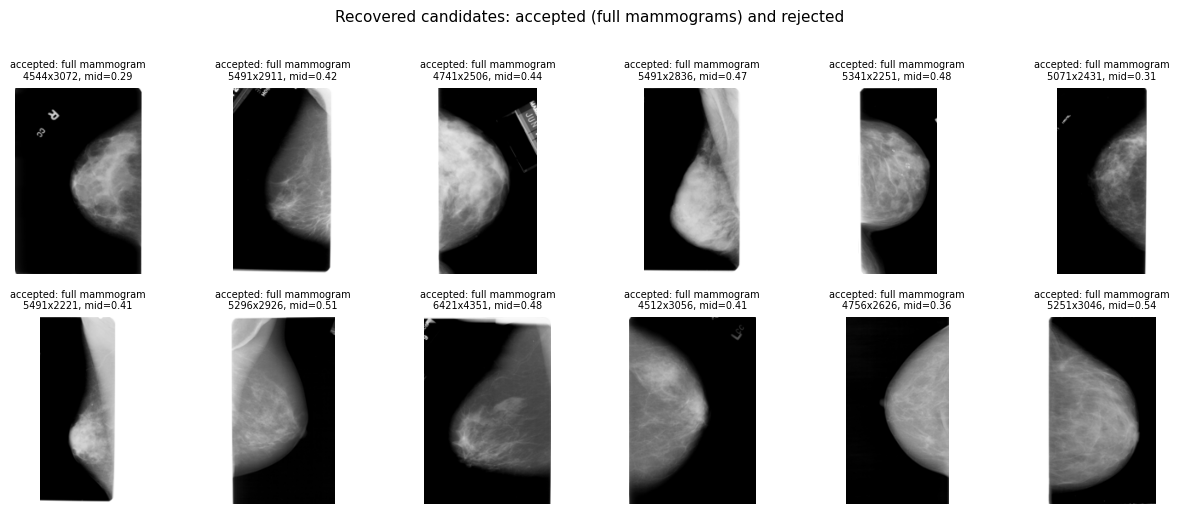

Saved -> /content/drive/MyDrive/MammoLens/figures/recovered_candidates_check.png


In [6]:
# STEP 1: classify the candidates whose dicom_info row has a blank SeriesDescription,
# so I only recover genuine full mammograms and not masks or crops.
#
# Fractions below are over all pixels of the greyscale image (0 to 255):
#   near_black = fraction <= 20 ; near_white = fraction >= 235
#   mid        = 1 - near_black - near_white   (tissue-grey values)
# Classification, applied in this order:
#   binary ROI mask : mid < 0.03                 (a mask has almost nothing between black and white)
#   cropped patch   : area < 0.10 * MED_AREA     (far smaller than a full image)
#   full mammogram  : area >= 0.25 * MED_AREA and 1.2 <= rows/cols <= 2.8 and mid >= 0.10
#   unknown         : anything else
# MED_AREA is the median pixel area of the labelled full mammograms (median
# dimensions 5236 x 3016). Only "full mammogram" is accepted.
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
Image.MAX_IMAGE_PIXELS = None          # these are 15 Mpx scans, so PIL's decompression-bomb guard gets in my way

DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
CSV_DIR     = os.path.join(DATA_DIR, 'csv')
FIG_DIR     = os.path.join(PROJECT_DIR, 'recovered_data_run', 'figures')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'recovered_data_run', 'results')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

dicom = pd.read_csv(os.path.join(CSV_DIR, 'dicom_info.csv'))
dicom['uid'] = dicom['SeriesInstanceUID'].astype(str)
dicom['rel'] = dicom['image_path'].str.replace(r'^CBIS-DDSM/', '', regex=True)
uid2rel  = dict(zip(dicom['uid'], dicom['rel']))
uid2name = dict(zip(dicom['uid'], dicom['PatientID'].astype(str)))
labelled = {k: set(dicom.loc[dicom['SeriesDescription'] == k, 'uid'])
            for k in ('full mammogram images', 'cropped images', 'ROI mask images')}
blank_uids = set(dicom.loc[dicom['SeriesDescription'].isna(), 'uid'])
MED_AREA = float((dicom.loc[dicom['SeriesDescription'] == 'full mammogram images', 'Rows']
                  * dicom.loc[dicom['SeriesDescription'] == 'full mammogram images', 'Columns']).median())
print(f'Labelled full mammograms: {len(labelled["full mammogram images"])}, '
      f'median area {MED_AREA / 1e6:.2f} Mpx | blank-description rows: {len(blank_uids)}')

CASE_FILES = ['mass_case_description_train_set.csv', 'mass_case_description_test_set.csv',
              'calc_case_description_train_set.csv', 'calc_case_description_test_set.csv']
frames = []
for fname in CASE_FILES:
    df = pd.read_csv(os.path.join(CSV_DIR, fname))
    dens_col = next(c for c in df.columns if 'density' in c.lower())
    frames.append(pd.DataFrame({
        'source': fname, 'patient_id': df['patient_id'],
        'side': df['left or right breast'].astype(str).str.upper(),
        'view': df['image view'].astype(str).str.upper(),
        'pathology': df['pathology'], 'density': pd.to_numeric(df[dens_col], errors='coerce'),
        'case_path': df['image file path']}))
case = pd.concat(frames, ignore_index=True)

def _uid_in(path, pool):
    for part in str(path).strip().split('/'):
        if part in pool:
            return part
    return None

case['full_uid']  = case['case_path'].map(lambda p: _uid_in(p, labelled['full mammogram images']))
case['blank_uid'] = case['case_path'].map(lambda p: _uid_in(p, blank_uids))
cand_mask = case['full_uid'].isna() & case['blank_uid'].notna()
CAND_UIDS = sorted(set(case.loc[cand_mask, 'blank_uid']))
print(f'Candidates: {len(CAND_UIDS)} images referenced by {int(cand_mask.sum())} abnormality rows')

def image_features(uid):
    rel = uid2rel[uid]
    path = os.path.join(DATA_DIR, rel)
    with Image.open(path) as im:
        h, w = im.height, im.width
        arr = np.asarray(im.convert('L'))
    nb, nw = float((arr <= 20).mean()), float((arr >= 235).mean())
    return {'uid': uid, 'rel': rel, 'rows': h, 'cols': w, 'aspect': h / w,
            'mpx': h * w / 1e6, 'file_mb': os.path.getsize(path) / 1e6,
            'near_black': nb, 'near_white': nw, 'mid': 1.0 - nb - nw}

def classify(f):
    if f['mid'] < 0.03:
        return 'binary ROI mask'
    if f['mpx'] * 1e6 < 0.10 * MED_AREA:
        return 'cropped patch'
    if f['mpx'] * 1e6 >= 0.25 * MED_AREA and 1.2 <= f['aspect'] <= 2.8 and f['mid'] >= 0.10:
        return 'full mammogram'
    return 'unknown'

rows = []
for i, uid in enumerate(CAND_UIDS, 1):
    rows.append(image_features(uid))
    if i % 50 == 0 or i == len(CAND_UIDS):
        print(f'  measured {i}/{len(CAND_UIDS)}', flush=True)
CANDIDATES = pd.DataFrame(rows)
CANDIDATES['class'] = CANDIDATES.apply(classify, axis=1)
# Matches both naming conventions in this dataset: the recovered images are
# named 'P_00038_LEFT_CC' and the labelled ones 'Calc-Training_P_00232_RIGHT_CC',
# with crops and masks carrying a trailing abnormality number.
NAME_RE = re.compile(r'(?:^|_)(P_\d+)_(LEFT|RIGHT)_(CC|MLO)(?:_(\d+))?(?:\.dcm)?$', re.I)
def _name_parts(uid):
    return NAME_RE.search(uid2name[uid])
CANDIDATES['name_has_abnormality_suffix'] = [
    bool(_name_parts(u)) and _name_parts(u).group(4) is not None for u in CANDIDATES['uid']]
CANDIDATES.to_csv(os.path.join(RESULTS_DIR, 'recovery_candidates.csv'), index=False)

print('\nClassification of the candidates:')
counts = CANDIDATES['class'].value_counts()
for k in ('full mammogram', 'cropped patch', 'binary ROI mask', 'unknown'):
    print(f'  {k:<18}{int(counts.get(k, 0)):>5}')
print('\nFeature summary by class (median):')
print(CANDIDATES.groupby('class')[['rows', 'cols', 'aspect', 'mpx', 'file_mb',
                                   'near_black', 'near_white', 'mid']].median().round(3).to_string())
print('\nNaming convention (crops and masks carry a trailing abnormality number, full images do not):')
print(pd.crosstab(CANDIDATES['class'], CANDIDATES['name_has_abnormality_suffix'],
                  rownames=['class'], colnames=['name has abnormality suffix']).to_string())

# Sanity-check my rule on images whose type I already know: 20 of each, fixed seed.
rng_chk = np.random.default_rng(42)
chk = []
for kind, pool in labelled.items():
    pick = rng_chk.choice(sorted(pool), size=min(20, len(pool)), replace=False)
    for uid in pick:
        f = image_features(uid)
        chk.append({'labelled as': kind, 'classified as': classify(f)})
CHECK = pd.DataFrame(chk)
print('\nRule applied to labelled images (20 per type), labelled against classified:')
print(pd.crosstab(CHECK['labelled as'], CHECK['classified as']).to_string())

ACCEPTED_UIDS = set(CANDIDATES.loc[CANDIDATES['class'] == 'full mammogram', 'uid'])
N_ACCEPTED = len(ACCEPTED_UIDS)
print(f'\nAccepted as full mammograms: {N_ACCEPTED} of {len(CANDIDATES)} candidates')

# Montage of 12 accepted and 12 rejected, so I can see what the rule decided.
acc = CANDIDATES[CANDIDATES['class'] == 'full mammogram'].head(12)
rej = CANDIDATES[CANDIDATES['class'] != 'full mammogram'].head(12)
show = pd.concat([acc.assign(panel='accepted'), rej.assign(panel='rejected')])
if len(show):
    ncol = 6
    nrow = int(np.ceil(len(show) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(2.1 * ncol, 2.6 * nrow))
    for ax in np.atleast_1d(axes).ravel():
        ax.axis('off')
    for ax, (_, r) in zip(np.atleast_1d(axes).ravel(), show.iterrows()):
        with Image.open(os.path.join(DATA_DIR, r['rel'])) as im:
            im = im.convert('L')
            im.thumbnail((220, 220))
            ax.imshow(np.asarray(im), cmap='gray', vmin=0, vmax=255)
        ax.set_title(f"{r['panel']}: {r['class']}\n{r['rows']}x{r['cols']}, mid={r['mid']:.2f}", fontsize=7)
    fig.suptitle('Recovered candidates: accepted (full mammograms) and rejected', fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    out = os.path.join(FIG_DIR, 'recovered_candidates_check.png')
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved ->', out)
if N_ACCEPTED == 0:
    print('\nNo candidate was accepted: Steps 2, 3 and 4 will be skipped and the existing '
          'manifests and v1 checkpoint reused for the re-evaluation in Step 5.')

<a id="t2"></a>
**Table 2.** Classification of the candidate images with a blank `SeriesDescription`: counts per class, the median of each measured feature within a class, the naming-convention cross-check, and the same rule applied to 20 labelled images of each known type (labelled type against classified type).

<a id="f1"></a>
**Figure 1.** Up to 12 accepted and 12 rejected candidates, shown as greyscale thumbnails with the class assigned by the rule, the pixel dimensions and the mid-grey fraction. Saved as `recovered_data_run/figures/recovered_candidates_check.png`.

All 246 candidates came back as full mammograms, with none classified as a cropped patch, an ROI mask or unknown. The measured features support that: a median of 5123.5 by 2952 pixels and 13.989 Mpx, close to the 14.46 Mpx median of the labelled full mammograms, with a near-black fraction of 0.566, a near-white fraction of 0.005 and a mid-grey fraction of 0.422. A binary mask would sit near zero on that last figure. The naming convention agrees independently, since none of the 246 carries an abnormality suffix, which crops and masks always do.

Figure 1 settles it by eye: every accepted panel shows a breast against a dark background, several with a laterality marker burnt into the corner. There is no panel of rejected images because nothing was rejected.

The check on labelled images is only partly reassuring, and I would rather say so. All 20 labelled full mammograms were classified as full mammograms, which is the property that matters here, since that is the class my rule accepts. But of 20 labelled ROI masks, 9 were called masks and 11 crops, and of 20 labelled crops, 12 were called masks and 8 crops. So my rule separates full mammograms from the rest cleanly while confusing the two classes it rejects with each other. That confusion has no effect on which candidates I accept, and it is consistent with CBIS-DDSM holding cropped ROI masks, which are small and binary at the same time. It does mean I should not present this rule as a general classifier of the three types.

<a id="s3"></a>
## 3 Preprocessing and patient-grouped split

<a id="s3-1"></a>
### 3.1 Rebuilding the manifest

This cell rebuilds my image manifest from the four case description files, now including the images accepted in Section 2.3. Rows that already resolved to a labelled full mammogram are linked exactly as in v1. Rows that pointed at an accepted image are linked to it through the UID embedded in their DICOM path, then joined to pathology and density by patient identifier, breast side and view: the `PatientID` field of the recovered image encodes those three things, and I keep the join only where they match the case row's own `patient_id`, `left or right breast` and `image view`. Any candidate with a missing density is dropped.

One more check is needed. A mammogram can appear twice in CBIS-DDSM, once in the mass collection and once in the calcification collection, under different UIDs. A recovered image whose patient, side and view already appear in my dataset would therefore add the same mammogram a second time, so I drop those and count them. The cell prints the cleaning counts for the new pipeline beside the v1 counts, which it recomputes from the same code rather than trusting the numbers I quoted in the audit, and then reports the new totals: images, patients, class balance and density distribution.

The label rule is unchanged from v1: an image counts as malignant if any abnormality on it is malignant, and both benign categories map to 0.

In [7]:
# STEP 2: rebuild the manifest with the images accepted in Section 2.3. I join the
# recovered rows to pathology and density by (patient, side, view), parsed from the
# image's own PatientID and checked against the case row's fields.
V1_COUNTS = {'raw abnormality rows (4 case CSVs)': 3568, 'after linkage to a full mammogram': 3286,
             'after removing paths with no file on disk': 3286,
             'after removing missing or invalid density': 3286,
             'unique images': 2857, 'patients': 1460}

case['label']   = (case['pathology'].astype(str).str.upper() == 'MALIGNANT').astype(int)
case['key_row'] = list(zip(case['patient_id'].astype(str), case['side'], case['view']))

def _img_key(uid):
    # (patient, side, view) from the image's own PatientID field, for both
    # naming conventions; None if the name does not parse.
    m = NAME_RE.search(uid2name.get(uid, ''))
    return (m.group(1), m.group(2).upper(), m.group(3).upper()) if m else None

# (a) rows that linked in v1, and (b) rows recovered through an accepted image
v1_rows = case[case['full_uid'].notna()].assign(rel=lambda d: d['full_uid'].map(uid2rel),
                                                recovered=False)
rec = case[case['full_uid'].isna() & case['blank_uid'].isin(ACCEPTED_UIDS)].copy()
rec['key_img'] = rec['blank_uid'].map(_img_key)
n_rec_rows = len(rec)
key_mismatch = int((rec['key_row'] != rec['key_img']).sum())
rec = rec[rec['key_row'] == rec['key_img']]
no_density = int(rec['density'].isna().sum())
rec = rec[rec['density'].notna()].assign(rel=lambda d: d['blank_uid'].map(uid2rel), recovered=True)
print(f'Recovered abnormality rows: {n_rec_rows} | dropped for a patient/side/view mismatch: '
      f'{key_mismatch} | dropped for missing density: {no_density} | kept: {len(rec)}')

def clean_counts(rows, tag):
    # Section 3.1's v1 cleaning, step by step, applied to any row set.
    s0 = len(case)                                   # raw rows are the same in both pipelines
    s1 = rows
    s2 = s1[s1['rel'].map(lambda p: os.path.isfile(os.path.join(DATA_DIR, p)))]
    s3 = s2[s2['density'].between(1, 4) & (s2['density'] % 1 == 0)]
    s4 = (s3.groupby('rel', as_index=False)
            .agg(label=('label', 'max'), density=('density', 'first'),
                 patient_id=('patient_id', 'first'), recovered=('recovered', 'max')))
    return {'raw abnormality rows (4 case CSVs)': s0, 'after linkage to a full mammogram': len(s1),
            'after removing paths with no file on disk': len(s2),
            'after removing missing or invalid density': len(s3),
            'unique images': len(s4), 'patients': s4['patient_id'].nunique()}, s4

v1_counts_live, v1_man = clean_counts(v1_rows, 'v1')
v2_counts, man = clean_counts(pd.concat([v1_rows, rec], ignore_index=True), 'v2')

# Drop a recovered image whose (patient, side, view) I already have: the same
# mammogram also exists under its mass or calc counterpart UID.
man['key'] = [(_img_key(u) if u in uid2name else None)
              for u in man['rel'].str.split('/').str[1]]
seen = set(man.loc[~man['recovered'].astype(bool), 'key'])
dup = man['recovered'].astype(bool) & man['key'].isin(seen)
print(f'Recovered images dropped as a duplicate view of an image already included: {int(dup.sum())}')
man = man[~dup].drop(columns=['key']).reset_index(drop=True)
v2_counts['unique images'] = len(man)
v2_counts['patients'] = man['patient_id'].nunique()
man['strat'] = man['label'].astype(str) + '_' + man['density'].astype(str)

print('\nCleaning counts, v1 pipeline beside v2:')
tab = pd.DataFrame({'v1 (audit)': pd.Series(V1_COUNTS), 'v1 (recomputed)': pd.Series(v1_counts_live),
                    'v2 (rebuilt)': pd.Series(v2_counts)})
tab['v2 minus v1'] = tab['v2 (rebuilt)'] - tab['v1 (recomputed)']
print(tab.to_string())
assert v1_counts_live == V1_COUNTS, 'the v1 pipeline no longer reproduces the audited counts'

n_recovered_final = int(man['recovered'].astype(bool).sum())
print(f'\nv2 dataset: {len(man)} images from {man["patient_id"].nunique()} patients '
      f'({n_recovered_final} recovered, {len(man) - n_recovered_final} carried over from v1)')
vc = man['label'].value_counts()
print(f'Class balance: benign {int(vc.get(0, 0))} ({vc.get(0, 0) / len(man):.1%}), '
      f'malignant {int(vc.get(1, 0))} ({vc.get(1, 0) / len(man):.1%})')
dens = pd.DataFrame({'images': man['density'].value_counts().reindex([1, 2, 3, 4]).fillna(0).astype(int)})
dens['share'] = (dens['images'] / len(man) * 100).round(1)
print('Density distribution (BI-RADS 1 to 4):')
print(dens.to_string())
print(f'Patients gained relative to v1: {man["patient_id"].nunique() - v1_counts_live["patients"]}')

Recovered abnormality rows: 282 | dropped for a patient/side/view mismatch: 0 | dropped for missing density: 0 | kept: 282
Recovered images dropped as a duplicate view of an image already included: 16

Cleaning counts, v1 pipeline beside v2:
                                           v1 (audit)  v1 (recomputed)  v2 (rebuilt)  v2 minus v1
raw abnormality rows (4 case CSVs)               3568             3568          3568            0
after linkage to a full mammogram                3286             3286          3568          282
after removing paths with no file on disk        3286             3286          3568          282
after removing missing or invalid density        3286             3286          3566          280
unique images                                    2857             2857          3085          228
patients                                         1460             1460          1565          105

v2 dataset: 3085 images from 1565 patients (228 recovered, 2857 carried

<a id="t3"></a>
**Table 3.** Cleaning counts for the v1 pipeline and the v2 rebuild, step by step, with the difference. The `v1 (audit)` column holds the counts reported when the problem was found, and `v1 (recomputed)` is the same pipeline rerun here; they must agree. Below the table: the recovered rows kept and dropped, the new dataset totals, class balance and density distribution.

The rebuild recovered all 282 abnormality rows: none was dropped for a patient, side and view mismatch against the image's own `PatientID`, and none for a missing density. Sixteen recovered images were then dropped because the same patient, side and view already appeared in the dataset under a mass or calcification counterpart UID, which would have put the same mammogram in twice.

Table 3 shows where my v2 pipeline diverges from v1. The two agree on the 3568 raw abnormality rows, and the v1 column reproduces my audited counts exactly, so the comparison is like for like. Linkage then keeps 3568 rows instead of 3286, the file check removes nothing in either version, and the density filter removes 2 rows in v2 against none in v1. After deduplication I have 3085 unique images from 1565 patients, an increase of 228 images and 105 patients.

The class balance barely moved, at 55.8% benign and 44.2% malignant against the 55.1% and 44.9% of my v1 training split. The density distribution is close to v1's too, with BI-RADS 2 the largest category at 38.9%. So the recovered images look like a broadly similar sample rather than a distinct subgroup, at least on the two attributes my manifest records.

<a id="s3-2"></a>
### 3.2 Re-splitting the rebuilt dataset

I keep the split procedure unchanged from v1, so that any difference in the results comes from the data rather than from how I divided it: `StratifiedGroupKFold` with seed 42, grouped on `patient_id` and stratified on the joint label and density key, taking fold 0 of a 7-fold split as test and fold 0 of a 6-fold split of the remainder as validation. That gives the 70/15/15 shape I intended, to within the rounding whole patients impose.

Re-splitting rather than adding the recovered images to my existing v1 partitions is a deliberate choice, and with hindsight it is the choice this whole investigation turns on. A patient absent from v1 can now appear, and 106 patients were missing entirely, so an incremental assignment would have to place new patients into old partitions and would leave the strata unbalanced. The cost is that my v2 test set is not my v1 test set, which matters for Section 5.8: the two models are measured on different samples, and some v2 test images were in the v1 training set. The cell writes the new manifests to `data/train.csv`, `data/val.csv` and `data/test.csv`, the same paths the configuration points at, and the v1 manifests stay in `initial_run/manifests/`. Then it prints the split, the class balance and the density balance, and asserts that no patient appears in more than one partition.

In [8]:
# STEP 3: re-split using the identical procedure and seed as v1, so only the data differs.
from sklearn.model_selection import StratifiedGroupKFold
SEED = 42

def grouped_holdout(frame, n_splits, seed):
    # Fold 0 of StratifiedGroupKFold as the held-out set (about 1/n_splits).
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    keep_idx, hold_idx = next(sgkf.split(frame, frame['strat'], frame['patient_id']))
    return frame.iloc[keep_idx].reset_index(drop=True), frame.iloc[hold_idx].reset_index(drop=True)

if N_ACCEPTED == 0:
    print('Step 1 accepted no images, so the v1 manifests stand unchanged; not re-splitting.')
    splits = {s: pd.read_csv(os.path.join(DATA_DIR, f'{s}.csv')) for s in ('train', 'val', 'test')}
else:
    trainval_df, test_df = grouped_holdout(man, n_splits=7, seed=SEED)          # test about 14%
    train_df, val_df = grouped_holdout(trainval_df, n_splits=6, seed=SEED)      # val about 14% of the total
    cols = ['image_path', 'label', 'density', 'patient_id']
    splits = {'train': train_df, 'val': val_df, 'test': test_df}
    for name, d in splits.items():
        d.rename(columns={'rel': 'image_path'})[cols].to_csv(
            os.path.join(DATA_DIR, f'{name}.csv'), index=False)
        print(f'wrote data/{name}.csv')
    splits = {s: pd.read_csv(os.path.join(DATA_DIR, f'{s}.csv')) for s in ('train', 'val', 'test')}

total = sum(len(d) for d in splits.values())
print(f'\nSplit of {total} images:')
for name, d in splits.items():
    vc = d['label'].value_counts()
    print(f'  {name:<5} {len(d):5d} images ({len(d) / total:5.1%}), {d["patient_id"].nunique():4d} patients, '
          f'malignant {int(vc.get(1, 0)):4d} ({vc.get(1, 0) / len(d):5.1%})')

print('\nDensity balance (percentage within each split):')
dens_pct = pd.DataFrame({n: d['density'].value_counts(normalize=True) for n, d in splits.items()}
                        ).reindex([1, 2, 3, 4]).fillna(0)
print((dens_pct * 100).round(1).to_string())
print('\nDensity counts:')
print(pd.DataFrame({n: d['density'].value_counts() for n, d in splits.items()}
                   ).reindex([1, 2, 3, 4]).fillna(0).astype(int).to_string())

ptr, pv, pte = (set(splits[s]['patient_id']) for s in ('train', 'val', 'test'))
assert not (ptr & pv) and not (ptr & pte) and not (pv & pte), 'patient overlap between splits'
print('\nOK: no patient_id appears in more than one split.')
print('\nFor the write-up: train {} images ({:.1%}), validation {} ({:.1%}), test {} ({:.1%}); '
      'malignant share {:.1%}, {:.1%} and {:.1%} respectively.'.format(
          len(splits['train']), len(splits['train']) / total, len(splits['val']), len(splits['val']) / total,
          len(splits['test']), len(splits['test']) / total,
          splits['train']['label'].mean(), splits['val']['label'].mean(), splits['test']['label'].mean()))

wrote data/train.csv
wrote data/val.csv
wrote data/test.csv

Split of 3085 images:
  train  2210 images (71.6%), 1115 patients, malignant  993 (44.9%)
  val     445 images (14.4%),  225 patients, malignant  172 (38.7%)
  test    430 images (13.9%),  225 patients, malignant  199 (46.3%)

Density balance (percentage within each split):
         train   val  test
density                   
1         15.2   8.5  10.7
2         38.8  40.7  37.4
3         29.6  35.5  32.1
4         16.3  15.3  19.8

Density counts:
         train  val  test
density                  
1          337   38    46
2          858  181   161
3          654  158   138
4          361   68    85

OK: no patient_id appears in more than one split.

For the write-up: train 2210 images (71.6%), validation 445 (14.4%), test 430 (13.9%); malignant share 44.9%, 38.7% and 46.3% respectively.


<a id="t4"></a>
**Table 4.** The v2 split: images, share of the dataset, patients and malignant count per partition, followed by the density composition as a percentage within each partition and as counts. The final lines confirm that the partitions share no patient and restate the figures in the form used in the prose.

The split gave 2210 training, 445 validation and 430 test images, or 71.6%, 14.4% and 13.9%, with 1115, 225 and 225 patients and no patient in more than one partition.

The stratification came out worse than in v1. The malignant share is 44.9% in training but 38.7% in validation and 46.3% in test, a spread of nearly eight percentage points; my v1 split was more even across its three partitions (Table 2 of `MammoLens.ipynb`). Density is more uneven still: BI-RADS 1 makes up 15.2% of training but only 8.5% of validation, and BI-RADS 4 reaches 19.8% of test against 16.3% of training. `StratifiedGroupKFold` can only move whole patients, and adding 105 new patients changed which whole-patient moves were available, so the same procedure with the same seed gave me a less even division than before.

That matters twice over. The validation set I use to select the checkpoint has a lower malignant share than the data the model trains on, and my test set has a higher one, so validation AUC is measured on a slightly different mix from either. It also means my v2 test set is not comparable image for image with v1's, which is why Section 5.8 also scores both models on the images common to both test sets.

<a id="s3-3"></a>
### 3.3 Image preprocessing and split composition

This cell sets up the image transforms and a dataset class that also returns each image's density, then prints how each manifest breaks down by class, by density and by the two together.

Each JPEG is opened with PIL, converted from greyscale into three identical RGB channels, resized to 224 by 224 pixels and normalised with the ImageNet channel means and standard deviations. The pretrained weights expect three-channel ImageNet-normalised input (Deng et al., 2009), which is why I replicate the single mammographic channel. The alternative was modifying the first convolution to take one channel, which would mean averaging or discarding pretrained filters for no clear benefit. Training images also get a random horizontal flip and a random rotation of up to 10 degrees. Flips are anatomically plausible, since left and right breasts are mirror images, and small rotations imitate variation in positioning. I left out heavier augmentation like elastic deformation or intensity changes, so my training images stay close to real acquisitions.

The resize does not preserve aspect ratio. A full mammogram is much taller than it is wide, 6256 by 3526 pixels for the example in Table 1c, so the breast gets squashed horizontally. Padding to a square first would avoid that, and I did not test what the distortion costs.

The loaders created here (`train_loader`, `val_loader`, `test_loader`) are not the ones used for training or evaluation. `src.train.train` and the evaluation cells build their own with `src.data.make_loader`, which applies the same transforms. What this cell contributes is the breakdown printed below.

In [9]:
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def build_transforms(image_size=224, train=False):
    norm = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    if train:
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(),     # light augmentation, train only
            transforms.RandomRotation(10),
            transforms.ToTensor(), norm,
        ])
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(), norm,
    ])

class MammoDensityDataset(Dataset):
    """Returns (image, label, density). Mammograms are grayscale -> 3ch for ImageNet weights."""
    def __init__(self, csv_path, data_dir, image_size=224, train=False):
        self.df = pd.read_csv(csv_path)
        self.data_dir = data_dir
        self.tf = build_transforms(image_size, train=train)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row['image_path']
        if not os.path.isabs(path):
            path = os.path.join(self.data_dir, path)
        img = self.tf(Image.open(path).convert('RGB'))
        return img, int(row['label']), int(row['density'])

def make_density_loader(split, batch_size=32, image_size=224, num_workers=2):
    is_train = split == 'train'
    ds = MammoDensityDataset(os.path.join(DATA_DIR, f'{split}.csv'),
                             DATA_DIR, image_size, train=is_train)
    return DataLoader(ds, batch_size=batch_size, shuffle=is_train,
                      num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                      drop_last=is_train)

train_loader = make_density_loader('train')
val_loader   = make_density_loader('val')
test_loader  = make_density_loader('test')

def print_dataset_stats():
    """Counts per class and per density category, for each split."""
    label_names = {0: 'benign', 1: 'malignant'}
    for split in ('train', 'val', 'test'):
        df = pd.read_csv(os.path.join(DATA_DIR, f'{split}.csv'))
        print(f'\n=== {split.upper()}  (n={len(df)}) ===')
        print('  per class:')
        for k, v in df['label'].map(label_names).value_counts().items():
            print(f'    {k:<10} {v:5d}  ({v/len(df):.1%})')
        print('  per density (BI-RADS):')
        for k, v in df['density'].value_counts().sort_index().items():
            print(f'    density {k}  {v:5d}  ({v/len(df):.1%})')
        print('  class x density:')
        print(pd.crosstab(df['label'].map(label_names), df['density']).to_string())

print_dataset_stats()


=== TRAIN  (n=2210) ===
  per class:
    benign      1217  (55.1%)
    malignant    993  (44.9%)
  per density (BI-RADS):
    density 1    337  (15.2%)
    density 2    858  (38.8%)
    density 3    654  (29.6%)
    density 4    361  (16.3%)
  class x density:
density      1    2    3    4
label                        
benign     194  456  354  213
malignant  143  402  300  148

=== VAL  (n=445) ===
  per class:
    benign       273  (61.3%)
    malignant    172  (38.7%)
  per density (BI-RADS):
    density 1     38  (8.5%)
    density 2    181  (40.7%)
    density 3    158  (35.5%)
    density 4     68  (15.3%)
  class x density:
density     1    2   3   4
label                     
benign     22  129  85  37
malignant  16   52  73  31

=== TEST  (n=430) ===
  per class:
    benign       231  (53.7%)
    malignant    199  (46.3%)
  per density (BI-RADS):
    density 1     46  (10.7%)
    density 2    161  (37.4%)
    density 3    138  (32.1%)
    density 4     85  (19.8%)
  class x d

<a id="t5"></a>
**Table 5.** Composition of each manifest as read back from `train.csv`, `val.csv` and `test.csv`: counts and percentages per class and per BI-RADS density, followed by the class by density cross-tabulation.

Table 5 agrees with Table 4 on every count, so the manifests I wrote to disk are the ones the split produced. The cross-tabulation exposes the thin cells. In validation, BI-RADS 1 holds 38 images, 16 of them malignant, and BI-RADS 4 holds 68 with 31 malignant. In the test set, BI-RADS 1 holds 46 images, 26 of them malignant, so that stratum has a higher malignant share than the test set as a whole. Sensitivity and specificity estimated inside cells this small rest on a few dozen images and move by several percentage points with one image.

<a id="s3-4"></a>
### 3.4 Local image cache

Reading thousands of separate JPEGs through the Drive mount is slow, so this optional cell copies every image my manifests reference to the Colab machine's local disk under `/content/data` and points `cfg.paths.data_dir` there. Only the manifest images are copied, not the whole archive. Files already present are skipped, so an interrupted copy resumes where it stopped when I rerun the cell. The manifests stay on Drive, which works because Sections 3.1 and 3.2 store the image paths relative to the data folder.

I preferred a local copy to reading straight from Drive because the cost of Drive reads recurs every epoch while the copy is paid once per session. My code comment quotes per-epoch timings for both options, and no output in this notebook supports those figures, so I do not rely on them here. Section 5.6.4 measures it properly, and the answer is far less flattering to this cell than the comment implies.

In [10]:
# OPTIONAL but recommended: copy the images referenced by the manifests to
# Colab local disk (/content). Reading thousands of small JPEGs over the Drive
# FUSE mount is the training bottleneck (~456 s/epoch in our run); local SSD
# makes training GPU-bound (~15-30 s/epoch). Only the ~2.9k images actually
# used are copied, and it's idempotent + resumable (skips files already present).
USE_LOCAL_COPY = True

if USE_LOCAL_COPY:
    import shutil
    from concurrent.futures import ThreadPoolExecutor

    LOCAL_DATA = '/content/data'
    rels = pd.concat([pd.read_csv(os.path.join(DATA_DIR, f'{s}.csv'))['image_path']
                      for s in ('train', 'val', 'test')]).unique()

    def _copy(rel):
        dst = os.path.join(LOCAL_DATA, rel)
        if os.path.isfile(dst):
            return 0
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy(os.path.join(DATA_DIR, rel), dst)
        return 1

    print(f'Copying {len(rels)} images -> {LOCAL_DATA} (one-time per session)...')
    with ThreadPoolExecutor(max_workers=8) as ex:
        copied = sum(ex.map(_copy, rels))
    print(f'Done: {copied} copied, {len(rels) - copied} already present.')

    # Point training at local disk; manifests stay on Drive (paths are relative).
    cfg.paths.data_dir = LOCAL_DATA
    print('cfg.paths.data_dir ->', cfg.paths.data_dir)
else:
    print('Local copy disabled; training will read images from Drive.')

Copying 3085 images -> /content/data (one-time per session)...
Done: 3085 copied, 0 already present.
cfg.paths.data_dir -> /content/data


All 3085 images were copied to the session's local disk, with none there beforehand, since this was a fresh Colab session. The count matches my rebuilt dataset in Table 3, so the cache covers every image the training and evaluation cells read. Section 5.6.4 measures whether this copy actually pays for itself, which in v1 I asserted but never tested.

<a id="s4"></a>
## 4 Model and training

<a id="s4-1"></a>
### 4.1 Retraining on the rebuilt dataset

The model is EfficientNet-B0 (Tan and Le, 2019) through timm (Wightman, 2019), starting again from ImageNet-pretrained weights, with my v1 hyperparameters unchanged: AdamW (Loshchilov and Hutter, 2019) at a learning rate of 0.0003 with weight decay of 0.0001, cosine annealing over 12 epochs (Loshchilov and Hutter, 2017), batch size 32, dropout 0.3 before the classifier, automatic mixed precision (Micikevicius et al., 2018), unweighted cross-entropy, no class weighting, a random horizontal flip at probability 0.5 with rotation within 10 degrees, inputs of 224 by 224 pixels and seed 42. Holding all of that fixed is what makes Section 5.8 worth reading: the data changed, the recipe did not.

Two things differ from v1 in how I record the run rather than in what it computes. `src/train.py` now appends one row per epoch to `recovered_data_run/results/training_log.csv` with the losses, the training and validation AUC, the learning rate used in that epoch and its duration, so I can actually inspect the learning curve afterwards; my v1 run left no such record and I regretted it. The same rows are stored inside the checkpoint, so a run resumed after a dropped session rewrites the log without a gap or a repeated epoch.

The second change is a safety measure I added after thinking about what could go wrong. `recovered_data_run/checkpoints/` still holds my v1 checkpoints, whose file names are the ones this run writes, and the training loop resumes from `last_checkpoint.pt` when it finds one. Without a guard it would have found my finished v1 run, reported that training was already complete and handed back the v1 model, and every result below would silently have described v1 on v2 data. Checkpoints now carry a `run_tag`, and the loop refuses to resume one whose tag does not match, so this run starts from ImageNet weights and overwrites the v1 files, which Section 1.3 has already copied to `initial_run/checkpoints/`.

One caveat about the training AUC in the log: it is computed on the augmented images as the epoch proceeds, with the weights changing underneath it, so it is only an indication. Section 5.6.2 computes a training AUC properly, in evaluation mode on unaugmented images.

In [11]:
# STEP 4: retrain from ImageNet-pretrained weights on my v2 split.
# run_tag='v2' stops the loop resuming the v1 checkpoint that is still sitting in
# checkpoints/, which would have reported v1 as v2. log_csv appends one row per
# epoch, which my v1 run never did.
from src.train import train
from src.model import build_model
import torch

LOG_CSV = os.path.join(RESULTS_DIR, 'training_log.csv')
if N_ACCEPTED == 0:
    print('Step 1 accepted no images, so the dataset is unchanged: skipping retraining and '
          'loading the v1 checkpoint for the re-evaluation below.')
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    _ckpt_path = os.path.join(cfg.paths.checkpoint_dir, 'best_model.pt')
    if not os.path.isfile(_ckpt_path):        # fall back to the snapshot taken in Section 1.3
        _ckpt_path = os.path.join(PROJECT_DIR, 'initial_run', 'checkpoints', 'best_model.pt')
    print('Loading', _ckpt_path)
    _ck = torch.load(_ckpt_path, map_location=device, weights_only=False)
    model = build_model(cfg).to(device)
    model.load_state_dict(_ck['model_state'])
    model.eval()
else:
    model = train(cfg, run_tag='v2', log_csv=LOG_CSV)

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Ignoring /content/drive/MyDrive/MammoLens/checkpoints/last_checkpoint.pt: run_tag None does not match 'v2'; training from ImageNet-pretrained weights.


Epoch 01/12 [train]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch 01/12 | train loss 2.2836 auc 0.5704 | val loss 1.7882 auc 0.6056 acc 0.6180 | lr 2.95e-04 |  419s  *best


...

Epoch 08/12 | train loss 0.4405 auc 0.8940 | val loss 0.7706 auc 0.7443 acc 0.6742 | lr 7.50e-05 |  419s


Epoch 09/12 [train]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch 09/12 | train loss 0.3526 auc 0.9252 | val loss 0.7568 auc 0.7476 acc 0.6854 | lr 4.39e-05 |  416s


Epoch 10/12 [train]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch 10/12 | train loss 0.3416 auc 0.9294 | val loss 0.7795 auc 0.7405 acc 0.6652 | lr 2.01e-05 |  420s
Early stopping at epoch 10 (no val AUC improvement for 5 epochs).
Done. Best val AUC = 0.7478 -> /content/drive/MyDrive/MammoLens/checkpoints/best_model.pt


The guard worked. The loop found my v1 checkpoint, reported that its `run_tag` of `None` does not match `v2`, ignored it and trained from ImageNet-pretrained weights. Without that, this run would have reported the v1 model as v2 and I might never have noticed.

Training ran for 10 of the 12 configured epochs and then stopped early, having gone 5 epochs without improving on the validation AUC of 0.7478 it reached at epoch 5. Validation AUC rose from 0.6056 to 0.7478 over those first five epochs and then moved inside a narrow band, ending at 0.7405, while training AUC kept climbing from 0.5704 to 0.9294 and training loss fell from 2.2836 to 0.3416. That divergence is the signature of a model fitting its training set well past the point where the fit transfers, and catching it is exactly what early stopping is for.

So my selected checkpoint comes from epoch 5, whereas v1's came from its final epoch. The two runs differ in how much training the kept model had, and Section 5.8 has to be read against that.

<a id="s4-2"></a>
### 4.2 Training log and learning curve

I read the log written during training back from disk, print it in full and plot it. Reading from the file rather than from memory means the table and the figure describe what was actually saved, which is what a later session would resume from or audit. The plot shows training and validation AUC against epoch with the best validation epoch marked: that is the epoch whose weights `best_model.pt` holds and which every evaluation below uses. The pattern to look for is a training curve that keeps climbing while the validation curve flattens or falls, and my v1 run could not be checked for it at all.

run_tag  epoch train_loss train_auc val_loss val_auc       lr  epoch_seconds
     v2      1     2.2836    0.5704   1.7882  0.6056 3.00e-04          419.5
     v2      2     1.2364    0.6612   0.9921  0.6653 2.95e-04          425.5
     v2      3     0.8891    0.7246   0.7785  0.7210 2.80e-04          420.6
     v2      4     0.7744    0.7603   0.9488  0.7105 2.56e-04          416.4
     v2      5     0.7211    0.7889   0.8132  0.7478 2.25e-04          416.3
     v2      6     0.5639    0.8433   0.7191  0.7397 1.89e-04          419.1
     v2      7     0.4996    0.8693   0.7255  0.7349 1.50e-04          417.7
     v2      8     0.4405    0.8940   0.7706  0.7443 1.11e-04          418.7
     v2      9     0.3526    0.9252   0.7568  0.7476 7.50e-05          416.4
     v2     10     0.3416    0.9294   0.7795  0.7405 4.39e-05          420.2

Epochs completed: 10 | best validation AUC 0.7478 at epoch 5 | final epoch validation AUC 0.7405
Total training time: 69.8 min (419 s per epoch on avera

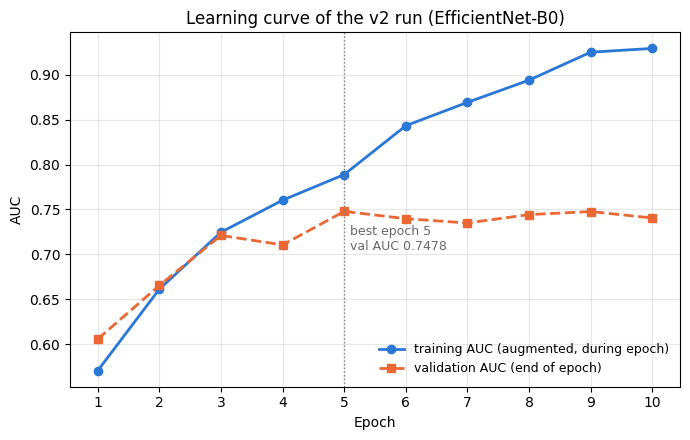

Saved -> /content/drive/MyDrive/MammoLens/figures/training_curve.png


In [12]:
# 4.2 Read back results/training_log.csv, print it, and plot the learning curve.
import matplotlib.pyplot as plt

if not os.path.isfile(LOG_CSV):
    print('No training log: Step 4 was skipped because Step 1 accepted no images.')
else:
    log = pd.read_csv(LOG_CSV)
    print(log.to_string(index=False, formatters={'train_loss': '{:.4f}'.format, 'train_auc': '{:.4f}'.format,
                                                 'val_loss': '{:.4f}'.format, 'val_auc': '{:.4f}'.format,
                                                 'lr': '{:.2e}'.format}))
    best = log.loc[log['val_auc'].idxmax()]
    print(f"\nEpochs completed: {len(log)} | best validation AUC {best['val_auc']:.4f} at epoch "
          f"{int(best['epoch'])} | final epoch validation AUC {log['val_auc'].iloc[-1]:.4f}")
    print(f"Total training time: {log['epoch_seconds'].sum() / 60:.1f} min "
          f"({log['epoch_seconds'].mean():.0f} s per epoch on average)")

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(log['epoch'], log['train_auc'], color='#2a78d6', marker='o', linewidth=2,
            markersize=6, label='training AUC (augmented, during epoch)')
    ax.plot(log['epoch'], log['val_auc'], color='#eb6834', marker='s', linestyle='--', linewidth=2,
            markersize=6, label='validation AUC (end of epoch)')
    ax.axvline(int(best['epoch']), color='gray', linestyle=':', linewidth=1)
    ax.annotate(f"best epoch {int(best['epoch'])}\nval AUC {best['val_auc']:.4f}",
                xy=(int(best['epoch']), best['val_auc']), xytext=(4, -28),
                textcoords='offset points', fontsize=9, color='dimgray')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('AUC')
    ax.set_xticks(log['epoch'])
    ax.set_title('Learning curve of the v2 run (EfficientNet-B0)')
    ax.legend(loc='lower right', fontsize=9, frameon=False)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    out = os.path.join(FIG_DIR, 'training_curve.png')
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved ->', out)

<a id="t6"></a>
**Table 6.** The per-epoch training log (`recovered_data_run/results/training_log.csv`): training loss and AUC, validation loss and AUC, the learning rate used in that epoch and its duration, followed by the best validation epoch and the total training time.

<a id="f2"></a>
**Figure 2.** Training and validation AUC by epoch for the v2 run, from `recovered_data_run/results/training_log.csv`. The training AUC is measured on augmented images while the weights change during the epoch, so it understates what the finished epoch would score; the validation AUC is measured at the end of the epoch in evaluation mode. The dotted line marks the epoch kept as `best_model.pt`. Saved as `recovered_data_run/figures/training_curve.png`.

Figure 2 shows the same log as Table 6 and makes the pattern plain: the two curves rise together to epoch 3, separate after epoch 5, and by epoch 10 the training AUC of 0.9294 sits far above the validation AUC of 0.7405. The best validation epoch, marked by the dotted line, is epoch 5.

Each epoch took between 416 and 425 seconds, so 69.8 minutes of training in total and 419 seconds on average. Since my v1 run left no log I have nothing to compare these times against directly, but Section 5.6.4 shows that image loading rather than the GPU accounts for most of it.

<a id="s5"></a>
## 5 Evaluation

<a id="s5-1"></a>
### 5.1 Test-set evaluation procedure

This cell scores my test images with the trained model and slices the metrics by breast density. `make_loader(cfg, 'test')` returns a loader that is not shuffled and keeps the last partial batch, so the predictions come out in the row order of `test.csv` and I can match each to its image's density. `evaluate_model` in `src/evaluate.py` takes the class with the higher softmax output, which for two classes is the same as a 0.5 threshold on the malignant probability. For the whole set and for each stratum it reports the number of images, the number of malignant images, ROC AUC, sensitivity, specificity and the confusion matrix.

I deliberately do not lead with accuracy. It folds missed cancers and false alarms into one number, whereas sensitivity and specificity keep the two apart, and in a cancer task they carry very different costs. The image count and malignant count are printed next to every metric so the evidence behind each number is visible.

I analyse density at two levels. CBIS-DDSM records it on a numeric scale from 1 to 4, which I read as the BI-RADS categories A to D (D'Orsi et al., 2013). My primary comparison pools categories 1 and 2 as non-dense (A/B) and 3 and 4 as dense (C/D), the conventional division. The four-way breakdown is supplementary, since BI-RADS 1 and 4 hold the fewest test images (Table 4). Dense breasts are the subgroup I care about because dense tissue both raises cancer risk and makes cancers harder to see (Boyd et al., 2007), and an aggregate score could hide a model that does worst in exactly those women.

In [13]:
from src.data import make_loader
from src.evaluate import evaluate_model, print_metrics

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Non-shuffled, drop_last=False test loader whose manifest carries `density`,
# so metrics can be sliced per stratum (aligned by row order).
test_loader = make_loader(cfg, 'test')

metrics = evaluate_model(model.to(device), test_loader, device, cfg, by_density=True)

# Aggregate + primary (A/B vs C/D) + supplementary (four-way BI-RADS).
# N and positive count print next to every metric so sample sizes are visible.
print_metrics(metrics)

AGGREGATE (all densities)
  stratum               N  pos     AUC    sens    spec      TN  FP  FN  TP
  all                 430  199   0.666   0.477   0.693     160  71 104  95

PRIMARY -- non-dense (A/B) vs dense (C/D)
  stratum               N  pos     AUC    sens    spec      TN  FP  FN  TP
  non-dense (A/B)     207  104   0.697   0.490   0.709      73  30  53  51
  dense (C/D)         223   95   0.634   0.463   0.680      87  41  51  44

SUPPLEMENTARY -- per BI-RADS density (small N at 1 & 4; interpret with care)
  stratum               N  pos     AUC    sens    spec      TN  FP  FN  TP
  density 1            46   26   0.640   0.462   0.650      13   7  14  12
  density 2           161   78   0.710   0.500   0.723      60  23  39  39
  density 3           138   57   0.588   0.404   0.630      51  30  34  23
  density 4            85   38   0.706   0.553   0.766      36  11  17  21


<a id="t7"></a>
**Table 7.** Test-set performance of the model returned by training: aggregate, by density group (primary) and by BI-RADS density category (supplementary). *pos* is the number of malignant images. Sensitivity and specificity treat malignant as the positive class, and TN, FP, FN and TP are confusion-matrix counts under the default decision rule.

<a id="s5-2"></a>
### 5.2 Aggregate performance

The model here is the one training returned, which after early stopping holds the weights of epoch 10 rather than of the best epoch. Over the 430 test images it reached an AUC of 0.666, finding 95 of the 199 malignant images (sensitivity 0.477) and clearing 160 of the 231 benign ones (specificity 0.693), leaving 104 false negatives.

That is the weaker of the two decision profiles in this notebook. Table 8, which uses the selected checkpoint, gives a very similar AUC (0.663) but a completely different operating point, with sensitivity 0.653 and specificity 0.567. The ranking ability is much the same in both; where the 0.5 threshold falls on the probability scale is not. In v1 the two tables were identical because the best epoch was also the last, so this split between them is new in v2 and comes from early stopping.

An AUC of 0.666 is the probability that a random malignant image is ranked above a random benign one. It is above chance and well below anything clinically useful, and it is lower than the 0.754 my v1 model reached on the v1 test set. Section 5.8 examines that gap properly, since the two test sets differ.

<a id="s5-3"></a>
### 5.3 Density-stratified performance

My v1 density pattern survives here in weakened form. With the final-epoch model, AUC is 0.697 in non-dense breasts (N = 207, 104 malignant) against 0.634 in dense breasts (N = 223, 95 malignant); sensitivity is 0.490 against 0.463 and specificity 0.709 against 0.680. With the selected checkpoint (Table 8) the ordering holds: 0.707 against 0.632.

The four-way breakdown no longer falls in a tidy order. AUC is highest at BI-RADS 2 (0.710, N = 161) and lowest at BI-RADS 3 (0.588, N = 138), with BI-RADS 4 at 0.706 and BI-RADS 1 at 0.640. In v1 my poorest stratum was BI-RADS 4; here BI-RADS 4 is among the better ones. With 46 images at BI-RADS 1 and 85 at BI-RADS 4, neither ordering carries much weight, and the fact that it flips between runs is a useful reminder of how little these per-category numbers can bear. Section 5.7.2 tests the grouped comparison instead of leaning on the ordering.

<a id="s5-4"></a>
### 5.4 Best-checkpoint evaluation and export

The previous cell evaluated the model object `train(cfg)` returned, which after training held the weights of the last epoch. What I report should come from the checkpoint validation actually selected, so this cell loads `best_model.pt` explicitly, rebuilds the network from the configuration, evaluates it on the same test loader and saves the results. The full nested metrics go to `recovered_data_run/results/test_metrics.json` and a flat table with one row per stratum to `recovered_data_run/results/test_metrics.csv`, which Section 5.5 plots. Drawing the chart from the saved file rather than typing numbers into plotting code removes one chance for me to introduce a transcription error between the evaluation and the figure.

In [14]:
import os, json
from src.data import make_loader
from src.model import build_model
from src.evaluate import evaluate_model, print_metrics

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RESULTS_DIR = os.path.join(cfg.paths.drive_root, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Evaluate the BEST checkpoint (best val AUC) so saved numbers are reproducible.
ckpt = torch.load(os.path.join(cfg.paths.checkpoint_dir, 'best_model.pt'), map_location=device, weights_only=False)
best_model = build_model(cfg).to(device)
best_model.load_state_dict(ckpt['model_state']); best_model.eval()

test_loader = make_loader(cfg, 'test')
metrics = evaluate_model(best_model, test_loader, device, cfg, by_density=True)
print_metrics(metrics)

# Full nested structure -> JSON.
with open(os.path.join(RESULTS_DIR, 'test_metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2, default=float)

# Flat one-row-per-stratum -> CSV (directly chartable).
KEYS = ['n', 'n_pos', 'accuracy', 'auc', 'sensitivity', 'specificity', 'tn', 'fp', 'fn', 'tp']
rows = [{'level': 'aggregate', 'stratum': 'all', **{k: metrics[k] for k in KEYS}}]
for name, m in metrics['per_density_group'].items():
    rows.append({'level': 'group', 'stratum': name, **{k: m[k] for k in KEYS}})
for d, m in metrics['per_density'].items():
    rows.append({'level': 'density', 'stratum': f'BI-RADS {d}', **{k: m[k] for k in KEYS}})
pd.DataFrame(rows).to_csv(os.path.join(RESULTS_DIR, 'test_metrics.csv'), index=False)
print('\nSaved -> results/test_metrics.json and results/test_metrics.csv')

AGGREGATE (all densities)
  stratum               N  pos     AUC    sens    spec      TN  FP  FN  TP
  all                 430  199   0.663   0.653   0.567     131 100  69 130

PRIMARY -- non-dense (A/B) vs dense (C/D)
  stratum               N  pos     AUC    sens    spec      TN  FP  FN  TP
  non-dense (A/B)     207  104   0.707   0.673   0.631      65  38  34  70
  dense (C/D)         223   95   0.632   0.632   0.516      66  62  35  60

SUPPLEMENTARY -- per BI-RADS density (small N at 1 & 4; interpret with care)
  stratum               N  pos     AUC    sens    spec      TN  FP  FN  TP
  density 1            46   26   0.573   0.615   0.450       9  11  10  16
  density 2           161   78   0.739   0.692   0.675      56  27  24  54
  density 3           138   57   0.585   0.596   0.494      40  41  23  34
  density 4            85   38   0.718   0.684   0.553      26  21  12  26

Saved -> results/test_metrics.json and results/test_metrics.csv


<a id="t8"></a>
**Table 8.** Test-set performance of `best_model.pt`, the checkpoint with the highest validation AUC. Rows and columns as in Table 7.

Table 8 differs from Table 7 for the first time in this project, because early stopping left the returned model 5 epochs past the selected one. The checkpoint gives an AUC of 0.663 against 0.666, so on ranking they are equivalent, but at the 0.5 threshold the checkpoint calls far more images malignant, 230 against 166, giving sensitivity 0.653 and specificity 0.567 against 0.477 and 0.693. The saved metrics, every figure below and the whole of Sections 5.6 and 5.7 use this checkpoint, because it is the model validation selected.

The false negative count is the figure I keep coming back to: 69 of 199 malignant images missed at this threshold, against 104 for the final-epoch model. Neither is anywhere near acceptable for a screening aid, and Section 5.7.3 shows what happens when I set the threshold to a fixed specificity instead.

<a id="s5-5"></a>
### 5.5 Density comparison chart

This cell reads the two density-group rows of `recovered_data_run/results/test_metrics.csv` and draws a grouped bar chart of AUC, sensitivity and specificity, with the aggregate AUC as a dashed reference line and each group's image and malignant counts under its label. I plot only the primary A/B against C/D comparison. Adding the four BI-RADS categories would give equal visual weight to strata of very different size and invite comparisons between bars whose uncertainty is nothing alike; those values stay in Table 8. The figure is also saved as `recovered_data_run/results/fig_density_stratified.png` for the report.

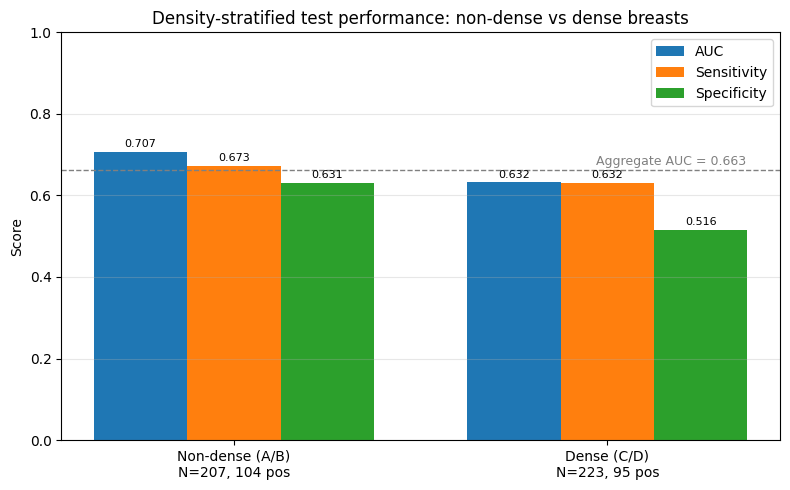

Saved -> /content/drive/MyDrive/MammoLens/results/fig_density_stratified.png


In [15]:
# --- Figure 4.1: density-stratified results bar chart ---
# Reads results/test_metrics.csv (written in the eval-save step) so the
# figure is generated directly from the saved metrics, not hand-typed.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = os.path.join(cfg.paths.drive_root, 'results')
m = pd.read_csv(os.path.join(RESULTS_DIR, 'test_metrics.csv'))

# Pull the two density-group rows and the aggregate.
agg = m[m['level'] == 'aggregate'].iloc[0]
grp = m[m['level'] == 'group'].set_index('stratum')

order = ['non-dense (A/B)', 'dense (C/D)']          # must match the keys in metrics['per_density_group']
labels = [f"Non-dense (A/B)\nN={int(grp.loc['non-dense (A/B)','n'])}, "
          f"{int(grp.loc['non-dense (A/B)','n_pos'])} pos",
          f"Dense (C/D)\nN={int(grp.loc['dense (C/D)','n'])}, "
          f"{int(grp.loc['dense (C/D)','n_pos'])} pos"]

auc  = [grp.loc[g, 'auc']         for g in order]
sens = [grp.loc[g, 'sensitivity'] for g in order]
spec = [grp.loc[g, 'specificity'] for g in order]
agg_auc = float(agg['auc'])

x = np.arange(len(order))
w = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w, auc,  w, label='AUC')
b2 = ax.bar(x,      sens, w, label='Sensitivity')
b3 = ax.bar(x + w, spec, w, label='Specificity')

ax.axhline(agg_auc, color='gray', linestyle='--', linewidth=1)
ax.text(0.97, agg_auc + 0.012, f'Aggregate AUC = {agg_auc:.3f}',
        fontsize=9, color='gray', ha='left')

for bars in (b1, b2, b3):
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.set_title('Density-stratified test performance: non-dense vs dense breasts')
ax.legend()
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
out = os.path.join(RESULTS_DIR, 'fig_density_stratified.png')
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved ->', out)

<a id="f3"></a>
**Figure 3.** Test-set AUC, sensitivity and specificity for non-dense (BI-RADS A/B) and dense (BI-RADS C/D) breasts, from `best_model.pt`, with each group's image and malignant counts under its label. The dashed line marks the aggregate test AUC. Values are read from `recovered_data_run/results/test_metrics.csv` and match Table 8.

Figure 3 plots the middle block of Table 8 and adds no new numbers. The dense group's bars sit below the non-dense group's on all three metrics, and the aggregate AUC line at 0.663 falls between the two AUC bars. The visual gap is smaller than in the equivalent v1 figure, where the two AUCs were 0.8188 and 0.6950 (Table 11). Section 5.7.2 shows that this gap is within sampling noise.

<a id="s5-6"></a>
### 5.6 Supplementary checks

This section adds the checks my headline evaluation does not cover: how well the model separates the classes on its own training data, exactly which hyperparameters produced it, and how much the storage location really affects loading time. Nothing is retrained. Every check uses `best_model.pt` and the manifests written in Section 3.2.

The cells are self-contained apart from one dependency: after a fresh Colab connection, run the Section 1.1 cell first, because it installs the packages in `requirements.txt` (timm included). The setup cell below reloads `configs/config.yaml` into a new object (`scfg`) rather than reusing `cfg`, which Section 3.4 modified, reads the three manifests and defines a small `record` helper. Every numeric result in Sections 5.6 and 5.7 passes through that helper, and Section 5.7.5 writes them all to `recovered_data_run/results/stat_tests.csv`, so the saved file and the printed outputs hold the same values. Outside Colab, the cell re-roots the Colab paths in the configuration to the local project folder.

In [16]:
# Section 5.6 setup: self-contained, so Sections 5.6 and 5.7 can run after a
# fresh Colab connect without re-running earlier sections. Nothing is retrained.
import os, sys, time, shutil, tempfile, copy
import numpy as np
import pandas as pd
import torch

IN_COLAB = 'google.colab' in sys.modules
COLAB_ROOT = '/content/drive/MyDrive/MammoLens'
if IN_COLAB:
    if not os.path.isdir('/content/drive/MyDrive'):
        from google.colab import drive
        drive.mount('/content/drive')
    PROJECT_DIR = COLAB_ROOT
else:  # local Jupyter: the notebook lives in <project>/notebooks
    here = os.getcwd()
    PROJECT_DIR = os.path.dirname(here) if os.path.basename(here) == 'notebooks' else here
os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

from src.config import load_config
scfg = load_config('configs/config.yaml')      # fresh copy; Section 3.3 mutates `cfg`
if not IN_COLAB:                                # re-root the Colab paths locally
    for k, v in vars(scfg.paths).items():
        setattr(scfg.paths, k, v.replace(COLAB_ROOT, PROJECT_DIR))

DRIVE_DATA  = scfg.paths.data_dir               # manifests + images on Drive
LOCAL_DATA  = '/content/data' if IN_COLAB else os.path.join(tempfile.gettempdir(), 'mammolens_data')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'recovered_data_run', 'results')
FIG_DIR     = os.path.join(PROJECT_DIR, 'recovered_data_run', 'figures')
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
scfg.paths.checkpoint_dir = os.path.join(PROJECT_DIR, 'recovered_data_run', 'checkpoints')
SEED   = scfg.project.seed
POS    = scfg.evaluate.positive_class
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Frozen manifests from Section 3.1; nothing below re-splits the data.
MANIFESTS = {s: pd.read_csv(os.path.join(DRIVE_DATA, f'{s}.csv')) for s in ('train', 'val', 'test')}

# Every new numeric result goes through record(); Section 5.7.5 writes them
# to results/stat_tests.csv. Keyed, so re-running a cell overwrites its rows.
STATS = {}
def record(section, analysis, stratum, metric, value, ci_low=np.nan, ci_high=np.nan, note=''):
    STATS[(section, analysis, stratum, metric)] = dict(
        section=section, analysis=analysis, stratum=stratum, metric=metric,
        value=value, ci_low=ci_low, ci_high=ci_high, note=note)

print('Environment:', 'Colab' if IN_COLAB else 'local Jupyter')
print('Device     :', device, f'({torch.cuda.get_device_name(0)})' if device.type == 'cuda' else '')
print('Manifests  :', {s: len(d) for s, d in MANIFESTS.items()})

Environment: Colab
Device     : cuda (Tesla T4)
Manifests  : {'train': 2210, 'val': 445, 'test': 430}


The three manifests load with 2210, 445 and 430 rows, matching Table 4, so Sections 5.6 to 5.8 work on the split Section 3.2 wrote. The run was on Colab with a Tesla T4, so the per-image scoring below uses the GPU.

<a id="s5-6-1"></a>
#### 5.6.1 Per-image predictions

This cell produces the per-image predictions that the rest of Sections 5.6, 5.7 and 5.8 depend on. In Colab it first makes sure every manifest image has a local copy, as in Section 3.4, because scoring 3085 images through the Drive mount would be slow. Then it rebuilds EfficientNet-B0 from the configuration, loads the weights in `best_model.pt` and puts the network in evaluation mode, which fixes the batch normalisation statistics and switches dropout off. Every image in the test, training and validation manifests goes through the evaluation transform only, a resize to 224 by 224 pixels and ImageNet normalisation with no flip or rotation, and I keep the softmax probability of the malignant class.

I score the training split with the evaluation transform on purpose. My training loader applies random augmentation and drops the last partial batch, so reusing it would give me a training AUC measured on altered images with some images missing, which I could not fairly compare with the validation and test AUCs. I score the validation split too, even though nothing asked for it separately, because Section 5.6.2 needs it and Section 5.7.3 uses it to set a threshold that is not fitted on the test set.

Each output file (`recovered_data_run/results/test_predictions.csv`, `recovered_data_run/results/train_predictions.csv` and `recovered_data_run/results/val_predictions.csv`) holds one row per image, with `image_id` (the SeriesInstanceUID folder name, unique per image), `patient_id`, the true `label`, `prob_malignant`, `density` and the relative `image_path`. The cell ends by checking the predictions against my evaluation in Section 5.4: the row count, the malignant count, the AUC and the confusion matrix at a threshold of 0.5 all have to match Table 8. I read those expected values from `recovered_data_run/results/test_metrics.csv` rather than writing them into the code, so the check follows the current dataset instead of the v1 figures I first wrote it against. A 0.5 threshold on the malignant probability makes the same decision as the arg-max rule in `src/evaluate.py`. Inference runs in full 32-bit precision, so the recomputed validation AUC can differ at the fourth decimal place from the value logged during training under mixed precision.

In [17]:
# 5.6.1 Per-image predictions from best_model.pt on the frozen splits (eval mode, no augmentation).
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, confusion_matrix
from src.data import build_transforms
from src.model import build_model

# Local copy of every manifest image (as in Section 3.3), created if this session lacks it.
if IN_COLAB:
    from concurrent.futures import ThreadPoolExecutor
    rels = pd.concat([d['image_path'] for d in MANIFESTS.values()]).unique()
    def _copy(rel):
        dst = os.path.join(LOCAL_DATA, rel)
        if os.path.isfile(dst):
            return 0
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy(os.path.join(DRIVE_DATA, rel), dst)
        return 1
    with ThreadPoolExecutor(max_workers=8) as ex:
        N_COPIED_561 = sum(ex.map(_copy, rels))
    print(f'Local copy: {N_COPIED_561} copied this session, {len(rels) - N_COPIED_561} already present')
IMG_ROOT = LOCAL_DATA if IN_COLAB else DRIVE_DATA

class EvalImages(Dataset):
    # Evaluation transform for every split, including train (no flip, no rotation).
    def __init__(self, df, root, image_size):
        self.paths = df['image_path'].tolist()
        self.root = root
        self.tf = build_transforms(image_size, train=False)
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        with Image.open(os.path.join(self.root, self.paths[i])) as im:
            return self.tf(im.convert('RGB'))

mcfg = copy.deepcopy(scfg)
mcfg.model.pretrained = False          # weights come from the checkpoint; skip the ImageNet download
ckpt = torch.load(os.path.join(scfg.paths.checkpoint_dir, 'best_model.pt'),
                  map_location=device, weights_only=False)
net = build_model(mcfg).to(device)
net.load_state_dict(ckpt['model_state'])
net.eval()
print(f"Loaded best_model.pt (epoch {ckpt['epoch'] + 1}, stored val_auc {ckpt['best_auc']:.4f})")

@torch.no_grad()
def predict(df):
    loader = DataLoader(EvalImages(df, IMG_ROOT, scfg.data.image_size), batch_size=64,
                        shuffle=False, num_workers=scfg.data.num_workers)
    out = [torch.softmax(net(x.to(device)).float(), dim=1)[:, POS].cpu().numpy() for x in loader]
    return np.concatenate(out)

PRED = {}
for split in ('test', 'train', 'val'):
    d = MANIFESTS[split]
    t0 = time.time()
    PRED[split] = pd.DataFrame({
        'image_id':       d['image_path'].str.split('/').str[1],   # SeriesInstanceUID folder
        'patient_id':     d['patient_id'],
        'label':          d['label'].astype(int),
        'prob_malignant': predict(d),
        'density':        d['density'].astype(int),
        'image_path':     d['image_path'],
    })
    PRED[split].to_csv(os.path.join(RESULTS_DIR, f'{split}_predictions.csv'), index=False)
    print(f'{split:<5} {len(d):5d} images scored in {time.time() - t0:5.0f} s -> results/{split}_predictions.csv')

# Checks against Table 8, read from the file rather than typed in, so this
# cell stays correct whatever the dataset version.
te = PRED['test']
auc_te = roc_auc_score(te['label'], te['prob_malignant'])
tn, fp, fn, tp = confusion_matrix(te['label'], (te['prob_malignant'] >= 0.5).astype(int), labels=[0, 1]).ravel()
n_mal = int(te['label'].sum())
ref = pd.read_csv(os.path.join(RESULTS_DIR, 'test_metrics.csv'))
ref = ref[ref['level'] == 'aggregate'].iloc[0]
ok_n = (len(te) == int(ref['n'])) and (n_mal == int(ref['n_pos']))
ok_auc = abs(auc_te - float(ref['auc'])) < 5e-4
ok_cm = (int(tn), int(fp), int(fn), int(tp)) == (int(ref['tn']), int(ref['fp']), int(ref['fn']), int(ref['tp']))
print(f"\nTest rows: {len(te)} (Table 8: {int(ref['n'])}) | malignant: {n_mal} "
      f"(Table 8: {int(ref['n_pos'])}) -> {'MATCH' if ok_n else 'MISMATCH'}")
print(f"Recomputed test AUC: {auc_te:.4f} (Table 8: {float(ref['auc']):.4f}) -> "
      f"{'MATCH' if ok_auc else 'MISMATCH'}")
print(f"Confusion at 0.5: TN {tn} FP {fp} FN {fn} TP {tp} (Table 8: TN {int(ref['tn'])} "
      f"FP {int(ref['fp'])} FN {int(ref['fn'])} TP {int(ref['tp'])}) -> {'MATCH' if ok_cm else 'MISMATCH'}")
assert ok_n, 'the predictions do not cover the same test manifest as the evaluation in Section 5.4'
record('5.6.1', 'prediction check', 'test', 'rows', len(te))
record('5.6.1', 'prediction check', 'test', 'malignant', n_mal)
record('5.6.1', 'prediction check', 'test', 'AUC recomputed', auc_te)
for k, v in dict(tn=tn, fp=fp, fn=fn, tp=tp).items():
    record('5.6.1', 'prediction check', 'test', f'{k.upper()} at 0.5', int(v))

Local copy: 0 copied this session, 3085 already present
Loaded best_model.pt (epoch 5, stored val_auc 0.7478)
test    430 images scored in    59 s -> results/test_predictions.csv
train  2210 images scored in   298 s -> results/train_predictions.csv
val     445 images scored in    61 s -> results/val_predictions.csv

Test rows: 430 (Table 8: 430) | malignant: 199 (Table 8: 199) -> MATCH
Recomputed test AUC: 0.6627 (Table 8: 0.6627) -> MATCH
Confusion at 0.5: TN 131 FP 100 FN 69 TP 130 (Table 8: TN 131 FP 100 FN 69 TP 130) -> MATCH


All three checks against Section 5.4 matched: 430 test rows with 199 malignant, a recomputed AUC of 0.6627 against the 0.6627 in Table 8, and an identical confusion matrix of 131 true negatives, 100 false positives, 69 false negatives and 130 true positives. So my predictions files describe the same model and the same manifest as the evaluation above, which is what everything in Sections 5.6 to 5.8 depends on.

The loaded checkpoint is from epoch 5 with a stored validation AUC of 0.7478, confirming that early stopping did not disturb which weights were kept. Scoring took 59 seconds for the test split, 298 for training and 61 for validation, and every image was already on local disk.

<a id="s5-6-2"></a>
#### 5.6.2 Discrimination on training, validation and test data

Comparing AUC across the three splits is the most direct check for overfitting I have. A model that has memorised its training images ranks them almost perfectly but ranks unseen images much less well, so a training AUC far above validation and test is the signature. The cell computes AUC from the saved probabilities for each split and prints it to four decimal places with the image and malignant counts, then the training minus validation difference. It also prints the validation AUC stored in the checkpoint next to the recomputed one, to check my predictions reproduce the figure used for model selection (Table 6 logs the same value for every epoch).

In [18]:
# 5.6.2 AUC on train / val / test from the per-image predictions.
AUC_SPLIT = {}
rows = []
for split in ('train', 'val', 'test'):
    p = PRED[split]
    AUC_SPLIT[split] = roc_auc_score(p['label'], p['prob_malignant'])
    rows.append({'split': split, 'N': len(p), 'malignant': int(p['label'].sum()), 'AUC': AUC_SPLIT[split]})
    record('5.6.2', 'discrimination by split', split, 'AUC', AUC_SPLIT[split])
print(pd.DataFrame(rows).to_string(index=False, formatters={'AUC': '{:.4f}'.format}))

gap_tv = AUC_SPLIT['train'] - AUC_SPLIT['val']
record('5.6.2', 'discrimination by split', 'train minus val', 'AUC difference', gap_tv)
print(f"\nTrain minus validation AUC: {gap_tv:+.4f}")
print(f"Validation AUC stored in checkpoint: {ckpt['best_auc']:.4f} | recomputed here: {AUC_SPLIT['val']:.4f}")

split    N  malignant    AUC
train 2210        993 0.8960
  val  445        172 0.7498
 test  430        199 0.6627

Train minus validation AUC: +0.1462
Validation AUC stored in checkpoint: 0.7478 | recomputed here: 0.7498


<a id="ts1"></a>
**Table S1.** AUC of `best_model.pt` on the training, validation and test splits, computed from the per-image predictions of Section 5.6.1 with the evaluation transform (no augmentation) for every split.

Table S1 confirms the overfitting Figure 2 suggested. In evaluation mode with no augmentation, the model scores 0.8960 on its own training images, 0.7498 on validation and 0.6627 on test, and the training minus validation difference is +0.1462.

Two things follow. The model has learned a good deal about my specific training images that does not transfer, which is hardly surprising with fixed hyperparameters and 2210 training images. And the drop from 0.7498 on validation to 0.6627 on test is far larger than the difference between validation and the value stored in the checkpoint (0.7498 against 0.7478, a gap explained by mixed precision during training). Since validation and test come from the same split procedure, that drop is either sampling noise between two sets of about 440 images, or a sign that I selected the checkpoint on a validation set whose composition differs from the test set. Table 4 showed that it does: 38.7% malignant in validation against 46.3% in test.

<a id="s5-6-3"></a>
#### 5.6.3 Hyperparameters

Section 4.1 lists my training settings in prose. This cell prints them from the code and the configuration that actually ran, so the two can be checked against each other rather than taken on faith. Most values come from `configs/config.yaml`. The ones fixed in code I read from the code objects themselves: the optimiser and the loss are built with the same helper functions `src/train.py` uses, and the augmentation entry is the transform pipeline `src.data.build_transforms` returns. Reading the values from the objects instead of retyping them keeps the table faithful to the code.

The cell also prints the last-modified time of the configuration, the three source files involved in training and `best_model.pt`, because a file edited after the checkpoint was written would no longer describe the run that produced it.

In [19]:
# 5.6.3 Every training setting with its value and source.
from datetime import datetime, timezone
from src.data import build_transforms
from src.train import _make_optimizer, _make_criterion

opt  = _make_optimizer(scfg, torch.nn.Linear(1, 1))   # same helper as training, on a dummy module
crit = _make_criterion(scfg, None, 'cpu')              # class weights off, so no loader is needed
tfs  = build_transforms(scfg.data.image_size, train=True).transforms
aug  = [repr(t) for t in tfs if type(t).__name__.startswith('Random')]
t, m = scfg.train, scfg.model
hp = pd.DataFrame([
    ('Optimiser',                      type(opt).__name__,                'config.yaml train.optimizer, via src/train.py'),
    ('Learning rate',                  t.learning_rate,                   'config.yaml'),
    ('Weight decay',                   t.weight_decay,                    'config.yaml'),
    ('Learning-rate schedule',         f'{t.scheduler}: CosineAnnealingLR, T_max = {t.epochs}, stepped once per epoch',
                                                                          'config.yaml + src/train.py'),
    ('Epochs',                         t.epochs,                          'config.yaml'),
    ('Batch size',                     t.batch_size,                      'config.yaml'),
    ('Dropout before classifier',      m.drop_rate,                       'config.yaml'),
    ('Mixed precision (AMP)',          f'{t.mixed_precision} (applied on CUDA only)', 'config.yaml + src/train.py'),
    ('Early stopping patience',        f'{t.early_stopping_patience} epochs', 'config.yaml'),
    ('Early stopping monitor',         'validation AUC; best_model.pt saved on improvement', 'src/train.py'),
    ('Loss',                           type(crit).__name__,               'src/train.py'),
    ('Class weighting',                t.use_class_weights,               'config.yaml'),
    ('Augmentation (train only)',      ' + '.join(aug),                   'src/data.py'),
    ('Image size',                     f'{scfg.data.image_size} x {scfg.data.image_size} (aspect ratio not kept)', 'config.yaml + src/data.py'),
    ('Normalisation',                  'ImageNet mean and standard deviation', 'src/data.py'),
    ('Backbone',                       f'{m.name}, ImageNet-pretrained = {m.pretrained}, classes = {m.num_classes}', 'config.yaml'),
    ('Seed',                           scfg.project.seed,                 'config.yaml'),
], columns=['Setting', 'Value', 'Source'])
with pd.option_context('display.max_colwidth', 120):
    print(hp.to_string(index=False))

print('\nLast modified (UTC):')
for f in ('configs/config.yaml', 'src/train.py', 'src/data.py', 'src/model.py',
          os.path.relpath(os.path.join(scfg.paths.checkpoint_dir, 'best_model.pt'), PROJECT_DIR)):
    ts = datetime.fromtimestamp(os.path.getmtime(os.path.join(PROJECT_DIR, f)), timezone.utc)
    print(f'  {f:<28} {ts:%Y-%m-%d %H:%M}')

                  Setting                                                                                                            Value                                        Source
                Optimiser                                                                                                            AdamW config.yaml train.optimizer, via src/train.py
            Learning rate                                                                                                           0.0003                                   config.yaml
             Weight decay                                                                                                           0.0001                                   config.yaml
   Learning-rate schedule                                                    cosine: CosineAnnealingLR, T_max = 12, stepped once per epoch                    config.yaml + src/train.py
                   Epochs                                                  

<a id="ts2"></a>
**Table S2.** Training settings for the v2 `best_model.pt`, with the source of each value. Values marked `src/...` are read from the code objects rather than retyped. The list after the table gives the last-modified time of each file involved.

Table S2 confirms I held the recipe fixed: AdamW at a learning rate of 0.0003 with weight decay 0.0001, cosine annealing with `T_max` of 12, batch size 32, dropout 0.3, mixed precision, unweighted cross-entropy, no class weighting, horizontal flip at probability 0.5 with rotation within 10 degrees, 224-pixel inputs and seed 42. These are my v1 settings, so what differs between the runs is the data and the split, not the recipe.

One entry needs care. The configured number of epochs is 12, but training stopped at 10, so the cosine schedule was cut before completing its cycle: the learning rate at the last epoch was 4.39e-05 rather than the near-zero value it would have reached at epoch 12. My v1 run trained through all 12 epochs, so the two models did not follow identical schedules to their ends even though the configuration is identical.

The modification times are clean for this run. The configuration, `src/data.py` and `src/model.py` all predate the checkpoint, and `src/train.py` was last modified at 17:19 UTC on 22 September, before `best_model.pt` was written at 19:28 the same day. That edit is the one that added the per-epoch log and the run tag I use in Section 4.1.

<a id="s5-6-4"></a>
#### 5.6.4 Storage timing

My comment in Section 3.4 claims that reading images through the Drive mount made training slow and that a local copy fixed it, and no output ever supported the figures it quoted. This cell measures it. I draw 200 training images with a fixed seed, make sure each has a local copy, copying any that are missing, and time loading all 200 first from the Drive-mounted path and then from the local copy. By loading I mean what the data loader does to each image before it reaches the GPU: opening the JPEG, decoding it, converting it to three channels, resizing and normalising. The cell prints seconds per image and a projected time per epoch, worked out by multiplying by the number of images an epoch actually processes, which is the training-set size rounded down to whole batches because the last partial batch is dropped.

Two limits apply. The loading here runs in a single process, whereas training used two loader workers, so my projection is a single-process figure rather than a forecast of wall-clock epoch time. And any image already read through the mount in this session, including by the copy step in Section 5.6.1, may be served from Colab's Drive cache, which would make the Drive figure look better than a cold read.

In [20]:
# 5.6.5 Time loading 200 training images from the Drive mount versus the local session copy.
from PIL import Image
from src.data import build_transforms

N_TIME = 200
rng_t = np.random.default_rng(SEED)
tr_paths = MANIFESTS['train']['image_path'].to_numpy()
sample = tr_paths[rng_t.choice(len(tr_paths), N_TIME, replace=False)]

made = 0                                   # create the local copy first where missing
for rel in sample:
    dst = os.path.join(LOCAL_DATA, rel)
    if not os.path.isfile(dst):
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy(os.path.join(DRIVE_DATA, rel), dst)
        made += 1
print(f'Local copy for the timing sample: {made} copied now, {N_TIME - made} already present')

tf_eval = build_transforms(scfg.data.image_size, train=False)
def time_load(root):
    t0 = time.perf_counter()
    for rel in sample:
        with Image.open(os.path.join(root, rel)) as im:
            tf_eval(im.convert('RGB'))
    return time.perf_counter() - t0

IMGS_PER_EPOCH = (len(tr_paths) // scfg.train.batch_size) * scfg.train.batch_size   # drop_last=True
rows = []
for name, root in (('Drive-mounted path', DRIVE_DATA), ('local session copy', LOCAL_DATA)):
    total = time_load(root)
    per = total / N_TIME
    rows.append({'source': name, 'path': root, 'total s (200 images)': round(total, 2),
                 's per image': round(per, 4), 'projected s per epoch': round(per * IMGS_PER_EPOCH, 1)})
    record('5.6.5', 'storage timing', name, 's per image', per, note=root)
    record('5.6.5', 'storage timing', name, 'projected s per epoch (single process)', per * IMGS_PER_EPOCH,
           note=f'{IMGS_PER_EPOCH} images per epoch')
print(f'Images per training epoch: {IMGS_PER_EPOCH} ({len(tr_paths)} rounded down to whole batches of {scfg.train.batch_size})\n')
print(pd.DataFrame(rows).to_string(index=False))

Local copy for the timing sample: 0 copied now, 200 already present
Images per training epoch: 2208 (2210 rounded down to whole batches of 32)

            source                                  path  total s (200 images)  s per image  projected s per epoch
Drive-mounted path /content/drive/MyDrive/MammoLens/data                 37.76       0.1888                  416.8
local session copy                         /content/data                 36.56       0.1828                  403.6


<a id="ts3"></a>
**Table S3.** Time to load (open, decode, resize and normalise) the same 200 training images from the Drive-mounted path and from the local session copy, single process, with the projected time per training epoch.

This result contradicts my own comment in Section 3.4, which I would rather correct than quietly leave standing. Loading 200 training images took 37.76 seconds from the Drive mount and 36.56 seconds from the local copy, which is 0.1888 against 0.1828 seconds per image, a saving of about 3%. Projected over the 2208 images an epoch processes, that is 416.8 seconds against 403.6 seconds, and the epochs in Table 6 actually took between 416 and 425 seconds. So image loading, not the GPU, accounts for essentially the whole epoch, and copying the data to local disk did not change that.

One caveat weakens the comparison but not the conclusion. Every image had already been read through the mount earlier in the session, so Colab's Drive cache may have served these reads and made the Drive figure better than a cold one. The stronger evidence is the agreement between my projection and the measured epoch times: whatever the storage, this run was loader-bound rather than GPU-bound, so the figures in my v1 comment, about 456 seconds per epoch on Drive against 15 to 30 seconds locally, are not reproduced here.

<a id="s5-7"></a>
### 5.7 Statistical analysis of the density gap

Section 5.3 reports performance separately for non-dense and dense breasts but cannot say how much of the difference is sampling noise, which is the first thing anyone should ask of it. I answer that here from `recovered_data_run/results/test_predictions.csv`, without running the model again. The non-dense and dense groups hold different patients, which the first cell checks, so I treat them as independent samples throughout.

<a id="s5-7-1"></a>
#### 5.7.1 Bootstrap confidence intervals

The bootstrap (Efron and Tibshirani, 1993) estimates how much a statistic varies from sample to sample by recomputing it on many resamples drawn with replacement from the data I have. I draw 2000 resamples with a fixed seed, and in each one the non-dense and dense groups are resampled separately, each keeping its own size, so every resample has the same density composition as my real test set. For each resample the cell computes AUC and, at a threshold of 0.5, sensitivity and specificity. The 95% interval runs from the 2.5th to the 97.5th percentile of the resampled values, which is the percentile method. Point estimates come from the full test set and should reproduce Table 8.

I do the resampling twice, with different units. Resampling images treats every image as independent, which they are not: most of my patients contribute two views of the same breast, so an image-level interval tends to be too narrow. Resampling whole patients keeps a patient's images together and accounts for that correlation (Field and Welsh, 2007). I report both side by side, and where they differ the patient-level one is the figure to quote. I preferred percentile intervals to normal-approximation ones because sensitivity and specificity are proportions whose sampling distributions can be skewed.

In [21]:
# 5.7.1 Stratified bootstrap CIs (2000 resamples, fixed seed) for AUC,
# sensitivity and specificity, resampling images and then whole patients.
from scipy.stats import norm
from sklearn.metrics import roc_auc_score

pred = pd.read_csv(os.path.join(RESULTS_DIR, 'test_predictions.csv'))
AB, CD = 'non-dense (A/B)', 'dense (C/D)'
pred['group'] = np.where(pred['density'].isin([1, 2]), AB, CD)
G = {AB: pred[pred['group'] == AB].reset_index(drop=True),
     CD: pred[pred['group'] == CD].reset_index(drop=True)}
shared = set(G[AB]['patient_id']) & set(G[CD]['patient_id'])
print(f"Test images {len(pred)} from {pred['patient_id'].nunique()} patients | "
      f"{AB}: {len(G[AB])} images, {G[AB]['patient_id'].nunique()} patients | "
      f"{CD}: {len(G[CD])} images, {G[CD]['patient_id'].nunique()} patients | "
      f"patients in both groups: {len(shared)}")
assert not shared, 'the density groups share patients; the independence assumption fails'

THR, N_BOOT = 0.5, 2000
def point_metrics(y, p, thr=THR):
    yhat = p >= thr
    tp = np.sum(yhat & (y == 1)); fn = np.sum(~yhat & (y == 1))
    tn = np.sum(~yhat & (y == 0)); fp = np.sum(yhat & (y == 0))
    return roc_auc_score(y, p), tp / (tp + fn), tn / (tn + fp)

def stratified_bootstrap(gA, gC, n_boot, seed, unit):
    # Resample within each density group. unit='image' or 'patient'; whole
    # patients move together, which respects the two views of one breast.
    rng = np.random.default_rng(seed)
    data = {}
    for k, g in ((AB, gA), (CD, gC)):
        clusters = list(g.groupby('patient_id').indices.values()) if unit == 'patient' else None
        data[k] = (g['label'].to_numpy(), g['prob_malignant'].to_numpy(), clusters)
    out = {AB: [], CD: [], 'all': []}
    skipped = 0
    while len(out['all']) < n_boot:
        draw = {}
        for k in (AB, CD):
            y, p, clusters = data[k]
            if clusters is None:
                idx = rng.integers(0, len(y), len(y))
            else:
                pick = rng.integers(0, len(clusters), len(clusters))
                idx = np.concatenate([clusters[i] for i in pick])
            draw[k] = (y[idx], p[idx])
        if min(min(yy.sum(), (1 - yy).sum()) for yy, _ in draw.values()) == 0:
            skipped += 1                    # AUC undefined with one class present
            continue
        for k in (AB, CD):
            out[k].append(point_metrics(*draw[k]))
        out['all'].append(point_metrics(np.r_[draw[AB][0], draw[CD][0]],
                                        np.r_[draw[AB][1], draw[CD][1]]))
    return {k: np.array(v) for k, v in out.items()}, skipped

BOOT_IMG, skip_img = stratified_bootstrap(G[AB], G[CD], N_BOOT, SEED, 'image')
BOOT_PAT, skip_pat = stratified_bootstrap(G[AB], G[CD], N_BOOT, SEED, 'patient')
POINT = {'all': point_metrics(pred['label'].to_numpy(), pred['prob_malignant'].to_numpy()),
         AB: point_metrics(G[AB]['label'].to_numpy(), G[AB]['prob_malignant'].to_numpy()),
         CD: point_metrics(G[CD]['label'].to_numpy(), G[CD]['prob_malignant'].to_numpy())}
print(f'Bootstrap: {N_BOOT} resamples per unit, seed {SEED}; '
      f'resamples skipped for a single class: {skip_img} (image) and {skip_pat} (patient)\n')

rows = []
for k, d in (('all', pred), (AB, G[AB]), (CD, G[CD])):
    for j, metric in enumerate(('AUC', 'sensitivity', 'specificity')):
        lo_i, hi_i = np.percentile(BOOT_IMG[k][:, j], [2.5, 97.5])
        lo_p, hi_p = np.percentile(BOOT_PAT[k][:, j], [2.5, 97.5])
        rows.append({'stratum': k, 'N': len(d), 'pos': int(d['label'].sum()), 'metric': metric,
                     'estimate': f'{POINT[k][j]:.3f}',
                     '95% CI (image)': f'[{lo_i:.3f}, {hi_i:.3f}]',
                     '95% CI (patient)': f'[{lo_p:.3f}, {hi_p:.3f}]'})
        record('5.7.1', 'bootstrap 95% CI (image-level)', k, metric, POINT[k][j], lo_i, hi_i,
               note=f'{N_BOOT} resamples, seed {SEED}, threshold {THR}')
        record('5.7.1', 'bootstrap 95% CI (patient-level)', k, metric, POINT[k][j], lo_p, hi_p,
               note=f'{N_BOOT} resamples, seed {SEED}, threshold {THR}')
print(pd.DataFrame(rows).to_string(index=False))

Test images 430 from 225 patients | non-dense (A/B): 207 images, 104 patients | dense (C/D): 223 images, 121 patients | patients in both groups: 0
Bootstrap: 2000 resamples per unit, seed 42; resamples skipped for a single class: 0 (image) and 0 (patient)

        stratum   N  pos      metric estimate 95% CI (image) 95% CI (patient)
            all 430  199         AUC    0.663 [0.611, 0.711]   [0.604, 0.719]
            all 430  199 sensitivity    0.653 [0.585, 0.718]   [0.586, 0.723]
            all 430  199 specificity    0.567 [0.504, 0.633]   [0.491, 0.638]
non-dense (A/B) 207  104         AUC    0.707 [0.638, 0.775]   [0.613, 0.783]
non-dense (A/B) 207  104 sensitivity    0.673 [0.585, 0.760]   [0.577, 0.767]
non-dense (A/B) 207  104 specificity    0.631 [0.536, 0.724]   [0.505, 0.736]
    dense (C/D) 223   95         AUC    0.632 [0.555, 0.702]   [0.546, 0.709]
    dense (C/D) 223   95 sensitivity    0.632 [0.531, 0.727]   [0.535, 0.724]
    dense (C/D) 223   95 specificity    0

<a id="t9"></a>
**Table 9.** Test-set AUC, sensitivity and specificity (threshold 0.5) for each stratum, with 95% percentile bootstrap confidence intervals from 2000 resamples drawn within the density groups, resampling images and, separately, whole patients. Point estimates are computed on the full test set.

Table 9 attaches intervals to every headline number, and they are wider than I would like. The aggregate AUC of 0.663 has an image-level interval of [0.611, 0.711] and a patient-level interval of [0.604, 0.719]. For the two density groups, non-dense AUC is 0.707 [0.638, 0.775] and dense AUC is 0.632 [0.555, 0.702] at image level, with the patient-level intervals wider still at [0.613, 0.783] and [0.546, 0.709].

The two resampling units give similar answers, with the patient-level intervals wider by roughly a quarter on the group AUCs. That is the direction I expected, since my 430 test images come from 225 patients, so the images are not independent. The intervals for the two groups overlap substantially on every metric, which is my first indication that the density gap is not resolvable at this sample size; Section 5.7.2 tests it directly.

Specificity is the weakest number in the table: 0.567 overall, and 0.516 in dense breasts with an interval of [0.426, 0.602] that reaches barely above chance at its lower end.

<a id="s5-7-2"></a>
#### 5.7.2 Testing the density gap

What I want is the non-dense minus dense AUC difference. Because I resampled the two groups independently in Section 5.7.1, the differences between their resampled AUCs form a bootstrap distribution for the gap, and its 2.5th and 97.5th percentiles give me a 95% interval. For the test, each group's standard error is the standard deviation of its bootstrap AUCs, z is the observed difference divided by the square root of the sum of the squared standard errors, and the two-sided p-value comes from the standard normal distribution. The image-level version of this test is my primary result and the patient-level version sits beside it; if the patient-level interval is much wider, my image-level p-value is optimistic.

The third row swaps the bootstrap standard errors for the closed-form approximation of Hanley and McNeil (1982), which depends only on the AUC and the numbers of malignant and benign images. It is a check on the other two rather than a separate analysis. Where the methods disagree materially I report all of them and prefer the most conservative, a rule I fixed before seeing the numbers.

DeLong's test (DeLong, DeLong and Clarke-Pearson, 1988) is the usual choice for comparing AUCs, and it does not apply here. It is a paired test, designed for two AUCs measured on the same cases, such as two models or two readers scoring one test set, and its variance for the difference includes the covariance between them, which exists because every case contributes to both. In my comparison one model is scored on two disjoint groups of images from different patients. No case contributes to both AUCs, so there is nothing to pair and the covariance is zero by construction. With zero covariance the comparison reduces to a z-test on the difference with independent variances, which is the unpaired test I use. DeLong's test does fit the model-against-model comparison in Section 5.8, where both models score the same images, and I use a paired bootstrap there for the same reason.

In [22]:
# 5.7.2 Non-dense minus dense AUC: bootstrap intervals and unpaired z-tests.
aucA, aucC = POINT[AB][0], POINT[CD][0]
diff = aucA - aucC

def z_test(d, se_a, se_c):
    z = d / np.hypot(se_a, se_c)
    return z, 2 * norm.sf(abs(z))

def hanley_mcneil_se(auc, n_pos, n_neg):
    q1, q2 = auc / (2 - auc), 2 * auc ** 2 / (1 + auc)
    return np.sqrt((auc * (1 - auc) + (n_pos - 1) * (q1 - auc ** 2)
                    + (n_neg - 1) * (q2 - auc ** 2)) / (n_pos * n_neg))

yA, yC = G[AB]['label'].to_numpy(), G[CD]['label'].to_numpy()
methods = []
for name, boot in (('image-level bootstrap (primary)', BOOT_IMG), ('patient-level bootstrap', BOOT_PAT)):
    bd = boot[AB][:, 0] - boot[CD][:, 0]
    se_a, se_c = boot[AB][:, 0].std(ddof=1), boot[CD][:, 0].std(ddof=1)
    z, p = z_test(diff, se_a, se_c)
    methods.append((name, np.percentile(bd, [2.5, 97.5]), (se_a, se_c), z, p))
se_hm = (hanley_mcneil_se(aucA, int(yA.sum()), int((1 - yA).sum())),
         hanley_mcneil_se(aucC, int(yC.sum()), int((1 - yC).sum())))
z_hm, p_hm = z_test(diff, *se_hm)
methods.append(('Hanley-McNeil SE (normal CI)',
                (diff - 1.96 * np.hypot(*se_hm), diff + 1.96 * np.hypot(*se_hm)), se_hm, z_hm, p_hm))

print(f'AUC non-dense (A/B) = {aucA:.4f} | AUC dense (C/D) = {aucC:.4f} | difference = {diff:.4f}\n')
print(f"{'method':<34}{'95% CI of difference':>24}{'SE A/B':>9}{'SE C/D':>9}{'z':>8}{'p (two-sided)':>15}")
for name, ci, se, z, p in methods:
    print(f"{name:<34}{f'[{ci[0]:.4f}, {ci[1]:.4f}]':>24}{se[0]:>9.4f}{se[1]:>9.4f}{z:>8.3f}{p:>15.4f}")
    record('5.7.2', f'AUC gap: {name}', 'A/B minus C/D', 'difference', diff, ci[0], ci[1])
    for metric, v in (('SE A/B', se[0]), ('SE C/D', se[1]), ('z', z), ('p two-sided', p)):
        record('5.7.2', f'AUC gap: {name}', 'A/B minus C/D', metric, v)
p_primary = methods[0][4]
print(f"\nPrimary test: {'significant' if p_primary < 0.05 else 'not significant'} at the 0.05 level "
      f"(p = {p_primary:.4f}).")

AUC non-dense (A/B) = 0.7071 | AUC dense (C/D) = 0.6320 | difference = 0.0750

method                                95% CI of difference   SE A/B   SE C/D       z  p (two-sided)
image-level bootstrap (primary)          [-0.0257, 0.1784]   0.0358   0.0382   1.433         0.1518
patient-level bootstrap                  [-0.0446, 0.1869]   0.0427   0.0412   1.264         0.2061
Hanley-McNeil SE (normal CI)             [-0.0274, 0.1775]   0.0359   0.0380   1.436         0.1511

Primary test: not significant at the 0.05 level (p = 0.1518).


The non-dense minus dense AUC difference is 0.0750, and it is not statistically significant. My primary image-level test gives z = 1.433 and p = 0.1518, with a 95% interval of [-0.0257, 0.1784] that includes zero. The patient-level bootstrap is more conservative, as I expected, at z = 1.264 and p = 0.2061 with an interval of [-0.0446, 0.1869]. The Hanley and McNeil standard errors agree closely with the image-level bootstrap, at z = 1.436 and p = 0.1511, so the choice between those two makes no difference to the conclusion.

This is a change from v1, where the same test on the same code gave a difference of 0.1238, an interval of [0.0312, 0.2166] and p = 0.0116. My v2 data do not support the density gap that my v1 data appeared to show. Two readings are available and this notebook cannot separate them: the v1 result may have been an artefact of one particular test set, or the v2 gap may be real but smaller and now hidden by noise, since this confidence interval is wide enough to contain my entire v1 estimate. What I can say plainly is that the density gap is not established by either run on its own, and that a difference this size needs a test set several times larger to resolve.

<a id="s5-7-3"></a>
#### 5.7.3 Operating points at a specificity of 0.80

A threshold of 0.5 is arbitrary. A screening aid would more plausibly run at a fixed specificity, which caps the false-positive rate, and be judged by the sensitivity it reaches there. For each group, all images, non-dense and dense, the cell finds the lowest threshold on the malignant probability at which specificity is at least 0.80; among the thresholds that satisfy the constraint, that one gives the highest sensitivity. It reports the threshold, the specificity actually reached, since exactly 0.80 is not always attainable with a finite number of benign images, and the sensitivity. Setting a separate threshold per density group assumes density is known when the model is applied, which is reasonable because density is assessed as part of mammographic reporting (D'Orsi et al., 2013).

A threshold chosen on the test set is fitted to the test data, so the sensitivity it gives is flattering. The cell therefore reports a second version where each group's threshold is found on the validation predictions from Section 5.6.1 and applied unchanged to the test set. That is the fairer estimate of what a fixed operating point would deliver on images the model has not seen. Both appear in Table 10 and are saved to `recovered_data_run/results/operating_points.csv`.

In [23]:
# 5.7.3 Sensitivity at specificity >= 0.80, per stratum (test-fitted and validation-fitted thresholds).
TARGET_SPEC = 0.80

def threshold_at_spec(y, p, target=TARGET_SPEC):
    # Lowest threshold t (predict malignant if p >= t) with specificity >= target.
    neg = p[y == 0]
    for t in np.unique(np.r_[p, np.inf]):          # ascending
        if np.mean(neg < t) >= target:
            return t

def rates(y, p, t):
    yhat = p >= t
    tp = int(np.sum(yhat & (y == 1))); fn = int(np.sum(~yhat & (y == 1)))
    tn = int(np.sum(~yhat & (y == 0))); fp = int(np.sum(yhat & (y == 0)))
    return tn / (tn + fp), tp / (tp + fn), tp, fn, tn, fp

val = PRED['val'] if 'PRED' in globals() else pd.read_csv(os.path.join(RESULTS_DIR, 'val_predictions.csv'))
val = val.assign(group=np.where(val['density'].isin([1, 2]), AB, CD))
test_sets = {'all': pred, AB: G[AB], CD: G[CD]}
val_sets = {'all': val, AB: val[val['group'] == AB], CD: val[val['group'] == CD]}

rows = []
for k in ('all', AB, CD):
    y, p = test_sets[k]['label'].to_numpy(), test_sets[k]['prob_malignant'].to_numpy()
    for source, fit in (('test-fitted', test_sets[k]), ('validation-fitted', val_sets[k])):
        t = threshold_at_spec(fit['label'].to_numpy(), fit['prob_malignant'].to_numpy())
        spec, sens, tp, fn, tn, fp = rates(y, p, t)
        rows.append({'stratum': k, 'threshold source': source, 'threshold': t,
                     'test specificity': spec, 'test sensitivity': sens,
                     'TP': tp, 'FN': fn, 'TN': tn, 'FP': fp, 'N': len(y), 'pos': int(y.sum())})
        record('5.7.3', f'operating point ({source})', k, 'sensitivity at spec >= 0.80', sens,
               note=f'threshold {t:.6f}; achieved specificity {spec:.4f}')
op = pd.DataFrame(rows)
op.to_csv(os.path.join(RESULTS_DIR, 'operating_points.csv'), index=False)
print(op.to_string(index=False, formatters={'threshold': '{:.6f}'.format, 'test specificity': '{:.3f}'.format,
                                            'test sensitivity': '{:.3f}'.format}))
print('\nSaved -> results/operating_points.csv')

        stratum  threshold source threshold test specificity test sensitivity  TP  FN  TN  FP   N  pos
            all       test-fitted  0.863134            0.801            0.407  81 118 185  46 430  199
            all validation-fitted  0.853944            0.792            0.407  81 118 183  48 430  199
non-dense (A/B)       test-fitted  0.812414            0.806            0.433  45  59  83  20 207  104
non-dense (A/B) validation-fitted  0.742226            0.777            0.500  52  52  80  23 207  104
    dense (C/D)       test-fitted  0.899993            0.805            0.358  34  61 103  25 223   95
    dense (C/D) validation-fitted  0.926179            0.852            0.305  29  66 109  19 223   95

Saved -> results/operating_points.csv


<a id="t10"></a>
**Table 10.** Test-set sensitivity at a target specificity of 0.80, by density group. *Test-fitted*: the threshold is chosen on the test predictions themselves. *Validation-fitted*: the threshold is chosen on the validation predictions for the same group and applied unchanged to the test set. Specificity is the value reached on the test set; a case is called malignant when its probability is at or above the threshold.

At a fixed specificity of 0.80 my model finds few cancers. Fitting the threshold on the test set itself, which flatters the result, sensitivity is 0.407 overall at a threshold of 0.863134, 0.433 in non-dense breasts and 0.358 in dense breasts. Put plainly, roughly three in five malignant images are missed at a false-positive rate of one in five.

The validation-fitted thresholds, which are the honest version, give almost the same picture overall: 0.407 sensitivity at an achieved specificity of 0.792. Within the groups they diverge more. In non-dense breasts the validation threshold of 0.742226 lands at specificity 0.777 and sensitivity 0.500; in dense breasts the threshold of 0.926179 overshoots to specificity 0.852 and sensitivity drops to 0.305. That overshoot shows how little a validation set of a few hundred images constrains a per-group threshold, and it argues against setting density-specific operating points on data of this size.

The thresholds themselves are worth noting: 0.863134 overall and 0.926179 for dense breasts on a probability scale, nowhere near 0.5, which is another symptom of the calibration problem in Section 5.7.4.

<a id="s5-7-4"></a>
#### 5.7.4 Calibration by density

Discrimination is about ranking; calibration is about whether the probabilities mean what they say, for instance whether roughly 70% of the images given a probability near 0.7 really turn out malignant. Modern neural networks are often overconfident (Guo et al., 2017), and Figure 5 already showed me displayed probabilities of 1.00 and 0.00. The cell sorts each group's test images into 10 equal-width probability bins and compares the mean predicted probability in each bin with the observed fraction malignant. Both groups go on the same reliability diagram, with a panel underneath showing how many images fall in each bin. For each group it reports the expected calibration error, the absolute gap between predicted and observed rates averaged over bins and weighted by each bin's share of images (Naeini, Cooper and Hauskrecht, 2015). A perfectly calibrated model lies on the diagonal with an ECE of 0.

Bins holding only a few images give unstable estimates, which is why I plot the counts: a point far from the diagonal in a bin of five images tells me very little. The figure is saved as `recovered_data_run/figures/calibration_by_density.png`.

non-dense (A/B): ECE = 0.1835
    bin  n mean_pred frac_malignant
0.0-0.1 47     0.032          0.234
0.1-0.2 13     0.127          0.308
0.2-0.3 21     0.247          0.476
0.3-0.4  7     0.346          0.286
0.4-0.5 11     0.450          0.636
0.5-0.6 15     0.559          0.467
0.6-0.7 11     0.638          0.636
0.7-0.8 15     0.751          0.667
0.8-0.9 23     0.861          0.652
0.9-1.0 44     0.963          0.705 

dense (C/D): ECE = 0.2893
    bin  n mean_pred frac_malignant
0.0-0.1 40     0.037          0.275
0.1-0.2 19     0.159          0.316
0.2-0.3 15     0.251          0.600
0.3-0.4 11     0.354          0.364
0.4-0.5 16     0.455          0.312
0.5-0.6  7     0.558          0.429
0.6-0.7 10     0.647          0.100
0.7-0.8 15     0.748          0.467
0.8-0.9 32     0.847          0.469
0.9-1.0 58     0.960          0.586 



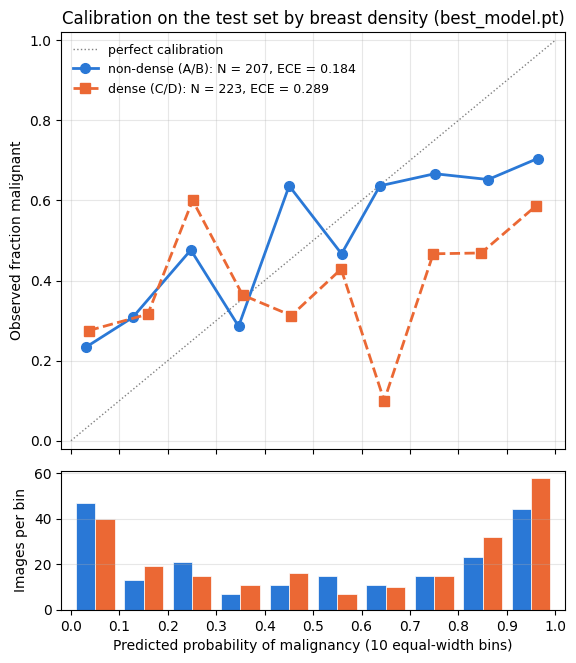

Saved -> /content/drive/MyDrive/MammoLens/figures/calibration_by_density.png


In [24]:
# 5.7.4 Reliability diagram (10 equal-width bins) and ECE for non-dense vs dense.
import matplotlib.pyplot as plt

EDGES = np.linspace(0, 1, 11)
def reliability(y, p):
    b = np.digitize(p, EDGES[1:-1])                # 0..9; p = 1.0 falls in the last bin
    t = pd.DataFrame({'bin': [f'{EDGES[i]:.1f}-{EDGES[i + 1]:.1f}' for i in range(10)],
                      'n': [int(np.sum(b == i)) for i in range(10)],
                      'mean_pred': [p[b == i].mean() if np.any(b == i) else np.nan for i in range(10)],
                      'frac_malignant': [y[b == i].mean() if np.any(b == i) else np.nan for i in range(10)]})
    ece = np.nansum(t['n'] / len(y) * (t['frac_malignant'] - t['mean_pred']).abs())
    return t, ece

STYLE = {AB: dict(color='#2a78d6', marker='o', linestyle='-'),
         CD: dict(color='#eb6834', marker='s', linestyle='--')}
fig, (ax, axn) = plt.subplots(2, 1, figsize=(6.5, 7.5), sharex=True,
                              gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})
ax.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=1, label='perfect calibration')
width = 0.04
for j, k in enumerate((AB, CD)):
    tab, ece = reliability(G[k]['label'].to_numpy(), G[k]['prob_malignant'].to_numpy())
    record('5.7.4', 'calibration (10 equal-width bins)', k, 'ECE', ece)
    ok = tab['n'] > 0
    ax.plot(tab.loc[ok, 'mean_pred'], tab.loc[ok, 'frac_malignant'], linewidth=2, markersize=7,
            label=f'{k}: N = {len(G[k])}, ECE = {ece:.3f}', **STYLE[k])
    centres = (EDGES[:-1] + EDGES[1:]) / 2 + (j - 0.5) * width
    axn.bar(centres, tab['n'], width=width, color=STYLE[k]['color'], edgecolor='white', linewidth=0.5)
    print(f'{k}: ECE = {ece:.4f}')
    print(tab.to_string(index=False, formatters={'mean_pred': '{:.3f}'.format, 'frac_malignant': '{:.3f}'.format}), '\n')

ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)       # pad so points at 0 or 1 are not clipped
ax.set_ylabel('Observed fraction malignant')
ax.set_title('Calibration on the test set by breast density (best_model.pt)')
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.grid(alpha=0.3)
axn.set_ylabel('Images per bin')
axn.set_xlabel('Predicted probability of malignancy (10 equal-width bins)')
axn.set_xticks(EDGES)
axn.grid(axis='y', alpha=0.3)
out = os.path.join(FIG_DIR, 'calibration_by_density.png')
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved ->', out)

<a id="f4"></a>
**Figure 4.** Reliability diagram for `best_model.pt` on the test set: non-dense (BI-RADS A/B, blue circles, solid line) and dense (BI-RADS C/D, orange squares, dashed line), with 10 equal-width probability bins. Top: observed fraction malignant against mean predicted probability in each non-empty bin; the dotted diagonal marks perfect calibration, and the legend gives each group's expected calibration error (ECE). Bottom: number of images in each bin. Saved as `recovered_data_run/figures/calibration_by_density.png`.

My model is badly calibrated, and worse in dense breasts. The expected calibration error is 0.1835 for non-dense and 0.2893 for dense images. Figure 4 shows the shape of the problem: both curves are far flatter than the diagonal. In the lowest bin the observed malignant fraction is 0.234 for non-dense and 0.275 for dense images, against mean predicted probabilities of 0.032 and 0.037; in the highest bin it is 0.705 and 0.586 against predictions of 0.963 and 0.960. So the model is confident at both ends and wrong about how confident it should be, which is the pattern Guo et al. (2017) report for modern networks.

The bin counts explain why the middle of the curve wanders: the extreme bins hold 47 and 44 images for non-dense and 40 and 58 for dense, while the bins between 0.3 and 0.7 hold as few as 7. The dip to 0.100 observed malignancy in the dense 0.6 to 0.7 bin rests on 10 images and I would not read anything into it.

For the report, the practical consequence is that these probabilities cannot be used as risk estimates, and that the thresholds in Section 5.7.3 sit where they do because the probability scale is compressed towards its ends, not because 0.86 means anything as a level of suspicion.

<a id="s5-7-5"></a>
#### 5.7.5 Saving the results

The last cell writes every value recorded through the `record` helper in Sections 5.6 and 5.7 to `recovered_data_run/results/stat_tests.csv`, one row per value with its section, analysis, stratum, metric, confidence limits where they exist, and a note. Table 10 was already saved to `recovered_data_run/results/operating_points.csv` in Section 5.7.3. Keeping the numbers in one long table lets me cite them in the report without copying values by hand out of the printed outputs, which is where transcription errors come from.

In [25]:
# 5.7.5 Write every recorded result to results/stat_tests.csv.
stat_df = pd.DataFrame(list(STATS.values()))
stat_df.to_csv(os.path.join(RESULTS_DIR, 'stat_tests.csv'), index=False)
print(f'Saved {len(stat_df)} rows -> results/stat_tests.csv')
print(stat_df.groupby('section').size().to_string())

Saved 56 rows -> results/stat_tests.csv
section
5.6.1     7
5.6.2     4
5.6.5     4
5.7.1    18
5.7.2    15
5.7.3     6
5.7.4     2


The file gathers up the values printed in Sections 5.6 to 5.8 and adds nothing new. Its row count depends only on which cells I ran, so a short file means some of the cells above were skipped.

<a id="s5-7-refs"></a>
#### References for Sections 5.6 to 5.8

I cite these works only in Sections 5.6 to 5.8, so I have listed them here rather than in Section 8, which I left as it was when I added these sections. They should be merged into it in the final version.

DeLong, E.R., DeLong, D.M. and Clarke-Pearson, D.L. (1988) 'Comparing the areas under two or more correlated receiver operating characteristic curves: a nonparametric approach', *Biometrics*, 44(3), pp. 837-845. doi:10.2307/2531595.

Efron, B. and Tibshirani, R.J. (1993) *An Introduction to the Bootstrap*. New York: Chapman and Hall.

Field, C.A. and Welsh, A.H. (2007) 'Bootstrapping clustered data', *Journal of the Royal Statistical Society: Series B (Statistical Methodology)*, 69(3), pp. 369-390. doi:10.1111/j.1467-9868.2007.00593.x.

Guo, C., Pleiss, G., Sun, Y. and Weinberger, K.Q. (2017) 'On calibration of modern neural networks', in *Proceedings of the 34th International Conference on Machine Learning*. PMLR 70, pp. 1321-1330.

Hanley, J.A. and McNeil, B.J. (1982) 'The meaning and use of the area under a receiver operating characteristic (ROC) curve', *Radiology*, 143(1), pp. 29-36. doi:10.1148/radiology.143.1.7063747.

Naeini, M.P., Cooper, G.F. and Hauskrecht, M. (2015) 'Obtaining well calibrated probabilities using Bayesian binning', in *Proceedings of the Twenty-Ninth AAAI Conference on Artificial Intelligence*. Austin, TX: AAAI Press, pp. 2901-2907.

<a id="s5-8"></a>
### 5.8 Comparing v1 with v2

This comparison has to be read with one limitation in mind: v1 and v2 are measured on different test sets, because Section 3.2 re-split the rebuilt dataset. A difference in test AUC therefore mixes three things, a change in the model, a change in which images are being scored, and sampling noise.

The cell reduces that confusion in two ways. It first rescores my v1 checkpoint on the v1 manifests, so both runs are summarised with the same code and the same bootstrap settings rather than by copying numbers out of my v1 outputs; the rescored predictions go to `recovered_data_run/results/v1_rescored/`, never into `initial_run/`. Then it evaluates both models on the images that are in the test set of both runs, a set neither model was trained on, which gives a like-for-like comparison on identical images with a paired bootstrap interval for the difference. That subset is small, so its interval is wide.

Everything is written to `recovered_data_run/results/v1_v2_comparison.csv`: dataset and split sizes, aggregate AUC, non-dense and dense AUC, the density gap with its interval and p-value, sensitivity and specificity per stratum, and training and validation AUC.

In [26]:
# STEP 6: v1 against v2, with both runs summarised by the same code so the
# comparison cannot turn on how I computed each one.
V1_RESULTS   = os.path.join(PROJECT_DIR, 'initial_run', 'results')
V1_MANIFESTS = os.path.join(PROJECT_DIR, 'initial_run', 'manifests')
V1_CKPT      = os.path.join(PROJECT_DIR, 'initial_run', 'checkpoints', 'best_model.pt')
V1_PRED_DIR  = os.path.join(RESULTS_DIR, 'v1_rescored')      # never write into initial_run/
os.makedirs(V1_PRED_DIR, exist_ok=True)

v1_man = {s: pd.read_csv(os.path.join(V1_MANIFESTS, f'{s}.csv')) for s in ('train', 'val', 'test')}

@torch.no_grad()
def score_with(ckpt_path, df):
    mc = copy.deepcopy(scfg)
    mc.model.pretrained = False
    ck = torch.load(ckpt_path, map_location=device, weights_only=False)
    net_ = build_model(mc).to(device)
    net_.load_state_dict(ck['model_state'])
    net_.eval()
    loader = DataLoader(EvalImages(df, IMG_ROOT, scfg.data.image_size), batch_size=64,
                        shuffle=False, num_workers=scfg.data.num_workers)
    p = np.concatenate([torch.softmax(net_(x.to(device)).float(), 1)[:, POS].cpu().numpy() for x in loader])
    return df.assign(prob_malignant=p)[['patient_id', 'label', 'prob_malignant', 'density', 'image_path']]

V1PRED = {}
for s in ('train', 'val', 'test'):
    f = os.path.join(V1_PRED_DIR, f'{s}_predictions.csv')
    if os.path.isfile(f):
        V1PRED[s] = pd.read_csv(f)
    else:
        V1PRED[s] = score_with(V1_CKPT, v1_man[s])
        V1PRED[s].to_csv(f, index=False)
    print(f'v1 {s}: {len(V1PRED[s])} images scored with initial_run/checkpoints/best_model.pt')

def summarise(pred_by_split, man_by_split, seed=SEED):
    # AUCs, density strata, gap test and split sizes for one run.
    te = pred_by_split['test'].copy()
    te['group'] = np.where(te['density'].isin([1, 2]), AB, CD)
    gA, gC = te[te['group'] == AB].reset_index(drop=True), te[te['group'] == CD].reset_index(drop=True)
    out = {}
    for s in ('train', 'val', 'test'):
        p = pred_by_split[s]
        out[f'{s} AUC'] = roc_auc_score(p['label'], p['prob_malignant'])
        out[f'{s} images'] = len(p)
        out[f'{s} patients'] = p['patient_id'].nunique()
    for name, d in (('all', te), (AB, gA), (CD, gC)):
        auc, sens, spec = point_metrics(d['label'].to_numpy(), d['prob_malignant'].to_numpy())
        out[f'AUC {name}'], out[f'sensitivity {name}'], out[f'specificity {name}'] = auc, sens, spec
        out[f'N {name}'], out[f'malignant {name}'] = len(d), int(d['label'].sum())
    boot_i, _ = stratified_bootstrap(gA, gC, N_BOOT, seed, 'image')
    boot_p, _ = stratified_bootstrap(gA, gC, N_BOOT, seed, 'patient')
    diff = out[f'AUC {AB}'] - out[f'AUC {CD}']
    lo_i, hi_i = np.percentile(boot_i[AB][:, 0] - boot_i[CD][:, 0], [2.5, 97.5])
    lo_p, hi_p = np.percentile(boot_p[AB][:, 0] - boot_p[CD][:, 0], [2.5, 97.5])
    z, p_val = z_test(diff, boot_i[AB][:, 0].std(ddof=1), boot_i[CD][:, 0].std(ddof=1))
    zp, p_pat = z_test(diff, boot_p[AB][:, 0].std(ddof=1), boot_p[CD][:, 0].std(ddof=1))
    out.update({'density gap (A/B minus C/D)': diff,
                'gap CI low (image-level)': lo_i, 'gap CI high (image-level)': hi_i,
                'gap z (image-level)': z, 'gap p (image-level)': p_val,
                'gap CI low (patient-level)': lo_p, 'gap CI high (patient-level)': hi_p,
                'gap z (patient-level)': zp, 'gap p (patient-level)': p_pat,
                'unique images': sum(len(m) for m in man_by_split.values()),
                'patients': pd.concat([m['patient_id'] for m in man_by_split.values()]).nunique()})
    return out

V2_SUM = summarise(PRED, {s: MANIFESTS[s] for s in ('train', 'val', 'test')})
V1_SUM = summarise(V1PRED, v1_man)

rows = [{'metric': k, 'v1': V1_SUM.get(k), 'v2': V2_SUM.get(k)} for k in V2_SUM]
cmp_df = pd.DataFrame(rows)
cmp_df['v2 minus v1'] = pd.to_numeric(cmp_df['v2'], errors='coerce') - pd.to_numeric(cmp_df['v1'], errors='coerce')

# Like-for-like: images held out by BOTH runs, scored by both models.
v2_test_ids = set(PRED['test']['image_path'])
common = sorted(v2_test_ids & set(v1_man['test']['image_path']))
print(f'\nImages in the test set of both runs: {len(common)}')
if len(common) >= 20:
    a = V1PRED['test'].set_index('image_path').loc[common]
    b = PRED['test'].set_index('image_path').loc[common]
    y = b['label'].to_numpy()
    auc1, auc2 = roc_auc_score(y, a['prob_malignant']), roc_auc_score(y, b['prob_malignant'])
    rng_c = np.random.default_rng(SEED)
    d_boot = []
    while len(d_boot) < N_BOOT:
        idx = rng_c.integers(0, len(y), len(y))          # paired: same images for both models
        if 0 < y[idx].sum() < len(idx):
            d_boot.append(roc_auc_score(y[idx], b['prob_malignant'].to_numpy()[idx])
                          - roc_auc_score(y[idx], a['prob_malignant'].to_numpy()[idx]))
    lo, hi = np.percentile(d_boot, [2.5, 97.5])
    print(f'Common held-out subset: N = {len(common)}, malignant {int(y.sum())} | '
          f'v1 model AUC {auc1:.4f} | v2 model AUC {auc2:.4f} | '
          f'paired difference {auc2 - auc1:+.4f} [95% CI {lo:+.4f}, {hi:+.4f}]')
    for k, v1v, v2v in (('common subset N', len(common), len(common)),
                        ('common subset AUC', auc1, auc2)):
        cmp_df.loc[len(cmp_df)] = {'metric': k, 'v1': v1v, 'v2': v2v,
                                   'v2 minus v1': (v2v - v1v) if isinstance(v1v, float) else 0}
    cmp_df.loc[len(cmp_df)] = {'metric': 'common subset paired AUC difference (CI)',
                               'v1': f'[{lo:.4f}, {hi:.4f}]', 'v2': auc2 - auc1, 'v2 minus v1': None}
else:
    print('Too few images are held out by both runs for a like-for-like comparison.')

cmp_df.to_csv(os.path.join(RESULTS_DIR, 'v1_v2_comparison.csv'), index=False)
with pd.option_context('display.float_format', lambda v: f'{v:,.4f}'):
    print('\n' + cmp_df.to_string(index=False))
print('\nSaved -> results/v1_v2_comparison.csv')

v1 train: 2052 images scored with checkpoints_v1/best_model.pt
v1 val: 405 images scored with checkpoints_v1/best_model.pt
v1 test: 400 images scored with checkpoints_v1/best_model.pt

Images in the test set of both runs: 48
Common held-out subset: N = 48, malignant 22 | v1 model AUC 0.7622 | v2 model AUC 0.5822 | paired difference -0.1801 [95% CI -0.3389, -0.0247]

                                  metric                 v1         v2  v2 minus v1
                               train AUC             0.9792     0.8960      -0.0832
                            train images         2,052.0000 2,210.0000     158.0000
                          train patients         1,043.0000 1,115.0000      72.0000
                                 val AUC             0.7554     0.7498      -0.0056
                              val images           405.0000   445.0000      40.0000
                            val patients           208.0000   225.0000      17.0000
                                test AUC   

/tmp/ipykernel_3848/4077466627.py:95: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cmp_df.loc[len(cmp_df)] = {'metric': 'common subset paired AUC difference (CI)',


<a id="t11"></a>
**Table 11.** v1 against v2: dataset and split sizes, AUC on each split, aggregate and density-stratified test performance, the density gap with its bootstrap interval and p-value at image and patient level, and sensitivity and specificity per stratum. The v1 column comes from rescoring `initial_run/checkpoints/best_model.pt` on the v1 manifests with the same code. The last rows cover the images held out by both runs, where both models are scored on identical data. Saved as `recovered_data_run/results/v1_v2_comparison.csv`.

Table 11 is the central result of this rebuild, and it is negative. Every headline measure is worse in v2 than in v1. Test AUC falls from 0.7541 to 0.6627, non-dense AUC from 0.8188 to 0.7071, dense AUC from 0.6950 to 0.6320, and specificity on all images from 0.7446 to 0.5671, while sensitivity is essentially unchanged at 0.6533 against 0.6568. Validation AUC barely moved, from 0.7554 to 0.7498, and training AUC fell from 0.9792 to 0.8960, so my v2 model fits its training data less tightly and its held-out data less well.

Someone could dismiss a comparison across different test sets as a change of sample, so the last rows settle it on identical images. Forty-eight images were held out by both runs and neither model was trained on any of them. On those, my v1 model scores 0.7622 and my v2 model 0.5822, a paired difference of -0.1801 with a 95% interval of [-0.3389, -0.0247] that excludes zero. That is like for like, and it says the newer model is worse on the same data, not merely on a harder sample.

I can state three candidate explanations, and this notebook settles none of them. The selected checkpoint came from epoch 5 rather than from a full 12 epochs, so my v2 model had less training when validation stopped improving. My v2 split is less even, with a validation set at 38.7% malignant selecting a checkpoint later judged on a test set at 46.3%, and Section 5.7.2 shows how wide the intervals are at this sample size. And the 228 recovered images, although confirmed as mammograms in Section 2.3, brought 105 patients that no previous run had seen, so the training distribution changed in ways my manifest's two attributes cannot describe. The subset comparison rests on 48 images and its interval is wide, but it points in one direction.

What I should not say is that more data improved the model, or that the rebuild was neutral. On this evidence it made the model worse. The first of the three explanations has since been tested directly and rejected: with early stopping disabled, the full 12-epoch schedule reproduced this run's test AUC to within 0.0067 and raised training AUC to 0.9783, so the model here was not undertrained (`MammoLens_recovered_data_full_schedule.ipynb`). Of the two candidates that remained, the later experiment in `MammoLens_original_split_with_recovered_images.ipynb` points at the re-split rather than the recovered images: with those images added to my v1 partitions, test AUC was 0.7527 against v1's 0.7541.

<a id="s6"></a>
## 6 Interpretability (Grad-CAM)

<a id="s6-1"></a>
### 6.1 Curated Grad-CAM gallery

Grad-CAM (Selvaraju et al., 2017) weights the feature maps of a convolutional layer by the gradient of a chosen class score and gives a coarse map of the regions that push that score up. I compute it at the network's final convolutional layer (`conv_head` in timm's EfficientNet) and always for the malignant class, whatever the model predicted, so every panel answers the same question: which regions pushed this image towards malignant? I preferred Grad-CAM to raw gradient saliency maps because it needs no change to the network and its class-specific, layer-level maps are less noisy than pixel-level gradients (Selvaraju et al., 2017). The price is resolution: the final convolutional layer of EfficientNet-B0 is heavily downsampled relative to the 224-pixel input, so a map can point at a region but cannot outline a lesion.

The cell loads `best_model.pt`, scores the whole test set and picks six cases by rule rather than by eye: the three correctly classified malignant images with the highest predicted probability, the two most confident correct malignant calls from dense (C/D) breasts not already chosen, and the malignant image given the lowest probability, which is the model's most confident miss. A fixed rule makes the gallery reproducible and stops me picking only the maps that flatter the model, though a rule favouring confident cases still gives a gallery that is not representative of typical behaviour.

Two display steps affect how the maps look. Each heatmap is masked to the breast, which I take as the largest connected region brighter than 0.05 once the ImageNet normalisation is undone, and rescaled inside that mask. Without the mask, strong activations over the black background or burnt-in labels could dominate the colour scale. With it, any such activation is hidden from view, which is a trade-off worth remembering while reading the figure.

Loaded best_model.pt (epoch 5, val_auc 0.7478)
Cases: 3 high-conf, 2 dense, 1 failure


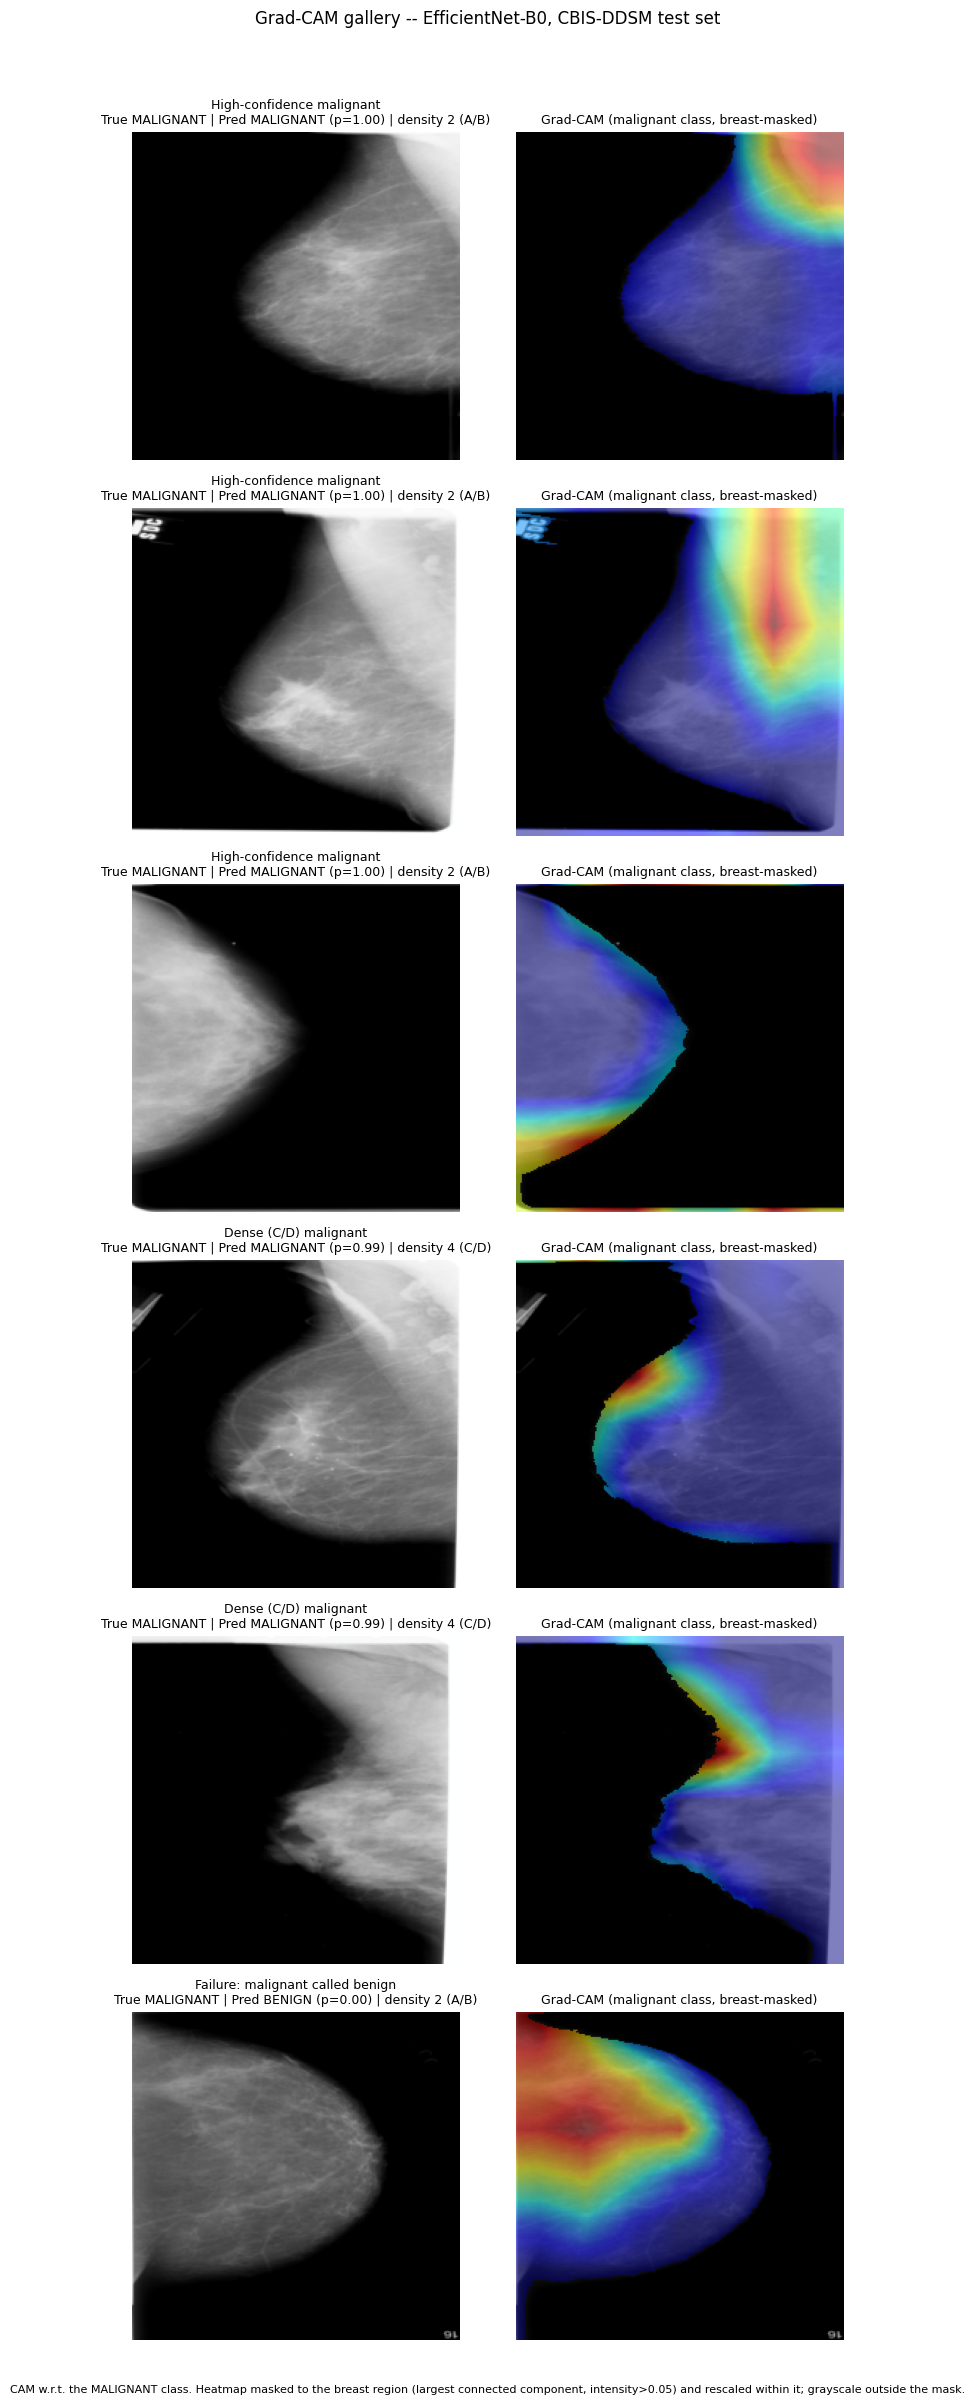

Saved -> /content/drive/MyDrive/MammoLens/results/gradcam_gallery.png


In [ ]:
import os, numpy as np, matplotlib.pyplot as plt, matplotlib.cm as cm
from scipy import ndimage
from src.data import make_loader
from src.model import build_model
from src.gradcam import GradCAM, last_conv_layer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
POS = cfg.evaluate.positive_class
MEAN = np.array([0.485, 0.456, 0.406]); STD = np.array([0.229, 0.224, 0.225])
MASK_THR = 0.05
RESULTS_DIR = os.path.join(cfg.paths.drive_root, 'results'); os.makedirs(RESULTS_DIR, exist_ok=True)

# Load best_model.pt explicitly (not whatever is in memory).
ckpt = torch.load(os.path.join(cfg.paths.checkpoint_dir, 'best_model.pt'), map_location=device, weights_only=False)
model = build_model(cfg).to(device); model.load_state_dict(ckpt['model_state']); model.eval()
print(f"Loaded best_model.pt (epoch {ckpt['epoch']+1}, val_auc {ckpt['best_auc']:.4f})")

# Score the whole test set (loader is non-shuffled -> order matches test.csv).
test_loader = make_loader(cfg, 'test'); ds = test_loader.dataset
probs = []
with torch.no_grad():
    for images, _ in test_loader:
        probs.extend(torch.softmax(model(images.to(device)).float(), 1)[:, POS].cpu().numpy())
df = ds.df.copy(); df['prob'] = probs; df['pred'] = (df['prob'] >= 0.5).astype(int)
dgroup = lambda d: 'A/B' if d in (1, 2) else 'C/D'

# Programmatic, curated selection.
correct_mal = df[(df.label == 1) & (df.pred == 1)].sort_values('prob', ascending=False)
sel_a = correct_mal.head(3)                                                   # (a) highest-confidence hits
sel_b = correct_mal[correct_mal.density.isin([3, 4])
                    & ~correct_mal.index.isin(sel_a.index)].head(2)           # (b) dense (C/D) hits
sel_c = df[(df.label == 1) & (df.pred == 0)].sort_values('prob').head(1)      # (c) most confident miss
selected = ([('High-confidence malignant', i) for i in sel_a.index]
            + [('Dense (C/D) malignant', i) for i in sel_b.index]
            + [('Failure: malignant called benign', i) for i in sel_c.index])
print(f"Cases: {len(sel_a)} high-conf, {len(sel_b)} dense, {len(sel_c)} failure")

cam_engine = GradCAM(model, last_conv_layer(model))
LBL = {0: 'BENIGN', 1: 'MALIGNANT'}
nrows = len(selected)
fig, axes = plt.subplots(nrows, 2, figsize=(8, 4 * nrows))
if nrows == 1: axes = axes[None, :]

for r, (tag, idx) in enumerate(selected):
    img_t, _ = ds[idx]
    cam = cam_engine(img_t.unsqueeze(0).to(device), class_idx=POS)   # CAM for MALIGNANT class
    disp = np.clip(img_t.numpy().transpose(1, 2, 0) * STD + MEAN, 0, 1)
    gray = disp.mean(2)

    m = gray > MASK_THR                                             # breast = largest non-black blob
    lbl, n = ndimage.label(m)
    if n > 0:
        sizes = ndimage.sum(np.ones_like(lbl), lbl, range(1, n + 1))
        m = lbl == (np.argmax(sizes) + 1)
    cam_m = cam * m
    if cam_m.max() > 0: cam_m = cam_m / cam_m.max()                 # rescale within breast
    heat = cm.jet(cam_m)[..., :3]
    overlay = disp.copy(); overlay[m] = 0.5 * disp[m] + 0.5 * heat[m]

    row = df.loc[idx]
    axes[r, 0].imshow(disp); axes[r, 0].axis('off')
    axes[r, 0].set_title(f"{tag}\nTrue {LBL[row.label]} | Pred {LBL[row.pred]} "
                         f"(p={row.prob:.2f}) | density {row.density} ({dgroup(row.density)})", fontsize=9)
    axes[r, 1].imshow(overlay); axes[r, 1].axis('off')
    axes[r, 1].set_title('Grad-CAM (malignant class, breast-masked)', fontsize=9)

fig.suptitle('Grad-CAM gallery -- EfficientNet-B0, CBIS-DDSM test set', fontsize=12, y=0.997)
fig.text(0.5, 0.004, f'CAM w.r.t. the MALIGNANT class. Heatmap masked to the breast region '
         f'(largest connected component, intensity>{MASK_THR}) and rescaled within it; grayscale outside the mask.',
         ha='center', fontsize=8)
fig.tight_layout(rect=[0, 0.02, 1, 0.98])
out = os.path.join(RESULTS_DIR, 'gradcam_gallery.png')
fig.savefig(out, dpi=160, bbox_inches='tight'); plt.show()
print('Saved ->', out)

<a id="f5"></a>
**Figure 5.** Grad-CAM gallery for six test images selected by rule from the predictions of `best_model.pt`. Left: the input after resizing to 224 by 224 pixels, titled with the selection group, true and predicted label, predicted malignant probability and BI-RADS density. Right: Grad-CAM for the malignant class, masked to the breast region and rescaled within it. Rows 1 to 3 are the highest-confidence correct malignant calls, rows 4 and 5 the most confident correct calls in dense (C/D) breasts, and row 6 the most confident miss. Saved as `recovered_data_run/results/gradcam_gallery.png`.

Figure 5 is less reassuring than my v1 gallery. The selection rule filled all six slots from the epoch 5 checkpoint: three high-confidence correct malignant calls, two from dense breasts and one failure. The three high-confidence cases are all BI-RADS 2 at a displayed probability of 1.00, the two dense cases are BI-RADS 4 at 0.99, and the failure is a BI-RADS 2 image given 0.00.

In most panels the strongest response sits on the breast boundary rather than inside the tissue, which is not what I want to see. Row 1 peaks at the upper right edge where the breast meets the background, row 3 along the lower border of the image, and rows 4 and 5 follow the anterior skin line. Row 2 is the exception, with a broad hot region over the upper breast interior. In the failure case the map covers most of the upper breast without a clear focus, which tells me little.

Edge-following maps are consistent with a model keying on breast outline, size or positioning rather than on lesions, and that reading fits the rest of my v2 results: high confidence, poor calibration and an AUC of 0.663. It is not proof. Grad-CAM at this resolution cannot localise a lesion, I made no comparison against the ROI masks, and saliency maps can look plausible while being insensitive to the weights (Adebayo et al., 2018). Six cases selected for confidence cannot characterise a model. Taken with Section 5.8, though, this gallery gives me no reason to think my v2 model is attending to the right things.

<a id="s7"></a>
## 7 Limitations

The central limitation is that this rebuild did not work as I intended and this notebook cannot say why. My dataset grew by 228 images and 105 patients, every recovered image was confirmed as a mammogram by pixel measurements, by the naming convention and by eye, and the retrained model is nonetheless worse: 0.6627 against 0.7541 on each run's own test set, and 0.5822 against 0.7622 on the 48 images both runs held out. I list three candidate explanations in Section 5.8 and test none of them in this notebook, but I did test two of them afterwards. The full-schedule control in `MammoLens_recovered_data_full_schedule.ipynb` rules out too little training, and `MammoLens_original_split_with_recovered_images.ipynb` adds these recovered images to my v1 partitions instead of re-splitting and reaches a test AUC of 0.7527, with a paired difference against v1 of -0.0041 on the 400 images both runs held out. So the re-split is what cost this run its performance, not the data I recovered. What none of my runs provides is repeated runs with different seeds.

The statistical base is thin for every claim. Each run is a single training run with a single seed and a single split, and my test set holds 430 images from 225 patients. The confidence intervals in Table 9 span roughly 0.10 in AUC, the density gap of 0.0750 is not significant at either resampling level (p = 0.1518 and p = 0.2061), and the like-for-like comparison rests on 48 images. My v1 run found a significant density gap and this one does not; with intervals this wide, neither result establishes the state of affairs.

Model selection is weaker than it looks, too. I chose the checkpoint on 445 validation images at 38.7% malignant and then judged it on 430 test images at 46.3% malignant, and training stopped at epoch 10 of a 12-epoch cosine schedule, so the learning rate never completed its cycle. Sections 5.2 and 5.4 show how much the operating point moves between the final-epoch model and the selected one even though their AUCs are within 0.003 of each other.

The dataset carries the constraints I noted in v1. CBIS-DDSM is a curated subset of DDSM, a collection of digitised screen-film mammograms (Heath et al., 2001; Lee et al., 2017) in which every image contains an annotated abnormality, so what I am doing is telling benign from malignant findings, not finding cancer among the mostly normal examinations of a screening programme. Performance on modern digital mammography, or in a screening population, cannot be inferred from these results. My re-split of the pooled official train and test files (Section 3.2) also means my figures cannot be set directly beside published results on the official test split.

Several preprocessing choices were made for simplicity and not tested. Downsampling full mammograms of several thousand pixels per side (Table 1c) to 224 by 224 pixels is likely to erase fine structures such as microcalcifications, which matters because calcification cases make up part of my data. The resize also distorts aspect ratio (Section 3.3). Labels were assigned per image by the any-malignant rule, and I merged the two benign categories. I did not record how many rows were removed during cleaning, and I did not check whether rows describing the same image always agree on density.

My density analysis cannot separate density from other case characteristics. The manifest keeps only path, label, density and patient, so abnormality type, subtlety and BI-RADS assessment, all present in the raw files (Table 1), were not available to check whether my dense and non-dense groups differ in case mix.

Sensitivity and specificity are reported at the default decision rule rather than at an operating point chosen on validation data. Grad-CAM was assessed on six rule-selected, high-confidence cases by eye alone, with no comparison against ROI masks and no saliency sanity checks (Section 6.1).

Two weaknesses are specific to this run. My classification rule in Section 2.3 separates full mammograms from everything else reliably in its check, but it confuses ROI masks with cropped patches, so I should not reuse it as a general three-way classifier. And 16 recovered images were dropped as duplicate views, which means CBIS-DDSM does hold the same mammogram under more than one UID; I never applied that check within the v1 images, so a small number of duplicate pairs may remain in both datasets.

Finally, the model is not usable as a probability estimator. Its expected calibration error is 0.1835 for non-dense and 0.2893 for dense breasts, at a fixed specificity of 0.80 it finds fewer than half the cancers, and the Grad-CAM maps in Section 6.1 frequently follow the breast edge rather than any lesion. This remains an academic prototype and nothing in it supports clinical use.

<a id="s8"></a>
## 8 References

Adebayo, J., Gilmer, J., Muelly, M., Goodfellow, I., Hardt, M. and Kim, B. (2018) 'Sanity checks for saliency maps', in *Advances in Neural Information Processing Systems 31 (NeurIPS 2018)*, pp. 9505-9515.

Boyd, N.F., Guo, H., Martin, L.J., Sun, L., Stone, J., Fishell, E., Jong, R.A., Hislop, G., Chiarelli, A., Minkin, S. and Yaffe, M.J. (2007) 'Mammographic density and the risk and detection of breast cancer', *New England Journal of Medicine*, 356(3), pp. 227-236. doi:10.1056/NEJMoa062790.

Deng, J., Dong, W., Socher, R., Li, L.-J., Li, K. and Fei-Fei, L. (2009) 'ImageNet: a large-scale hierarchical image database', in *2009 IEEE Conference on Computer Vision and Pattern Recognition*. Miami, FL: IEEE, pp. 248-255. doi:10.1109/CVPR.2009.5206848.

D'Orsi, C.J., Sickles, E.A., Mendelson, E.B. and Morris, E.A. (2013) *ACR BI-RADS Atlas: Breast Imaging Reporting and Data System*. 5th edn. Reston, VA: American College of Radiology.

Heath, M., Bowyer, K., Kopans, D., Moore, R. and Kegelmeyer, P. (2001) 'The Digital Database for Screening Mammography', in Yaffe, M.J. (ed.) *Proceedings of the Fifth International Workshop on Digital Mammography*. Madison, WI: Medical Physics Publishing, pp. 212-218.

Kaufman, S., Rosset, S., Perlich, C. and Stitelman, O. (2012) 'Leakage in data mining: formulation, detection, and avoidance', *ACM Transactions on Knowledge Discovery from Data*, 6(4), Article 15. doi:10.1145/2382577.2382579.

Lee, R.S., Gimenez, F., Hoogi, A., Miyake, K.K., Gorovoy, M. and Rubin, D.L. (2017) 'A curated mammography data set for use in computer-aided detection and diagnosis research', *Scientific Data*, 4, Article 170177. doi:10.1038/sdata.2017.177.

Loshchilov, I. and Hutter, F. (2017) 'SGDR: stochastic gradient descent with warm restarts', in *5th International Conference on Learning Representations (ICLR 2017)*. Toulon, France.

Loshchilov, I. and Hutter, F. (2019) 'Decoupled weight decay regularization', in *7th International Conference on Learning Representations (ICLR 2019)*. New Orleans, LA.

Micikevicius, P., Narang, S., Alben, J., Diamos, G., Elsen, E., Garcia, D., Ginsburg, B., Houston, M., Kuchaiev, O., Venkatesh, G. and Wu, H. (2018) 'Mixed precision training', in *6th International Conference on Learning Representations (ICLR 2018)*. Vancouver, Canada.

Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., Killeen, T., Lin, Z., Gimelshein, N., Antiga, L., Desmaison, A., Köpf, A., Yang, E., DeVito, Z., Raison, M., Tejani, A., Chilamkurthy, S., Steiner, B., Fang, L., Bai, J. and Chintala, S. (2019) 'PyTorch: an imperative style, high-performance deep learning library', in *Advances in Neural Information Processing Systems 32 (NeurIPS 2019)*, pp. 8024-8035.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M. and Duchesnay, É. (2011) 'Scikit-learn: machine learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825-2830.

Raghu, M., Zhang, C., Kleinberg, J. and Bengio, S. (2019) 'Transfusion: understanding transfer learning for medical imaging', in *Advances in Neural Information Processing Systems 32 (NeurIPS 2019)*, pp. 3347-3357.

Selvaraju, R.R., Cogswell, M., Das, A., Vedantam, R., Parikh, D. and Batra, D. (2017) 'Grad-CAM: visual explanations from deep networks via gradient-based localization', in *2017 IEEE International Conference on Computer Vision (ICCV)*. Venice: IEEE, pp. 618-626. doi:10.1109/ICCV.2017.74.

Tan, M. and Le, Q.V. (2019) 'EfficientNet: rethinking model scaling for convolutional neural networks', in *Proceedings of the 36th International Conference on Machine Learning*. PMLR 97, pp. 6105-6114.

Wightman, R. (2019) *PyTorch Image Models* [computer program]. Available at: https://github.com/huggingface/pytorch-image-models (Accessed: [DATE]).